# Understanding and Forecasting Individual Household Electric Power Consumption

For this project, we use minute-level data from a single household in France. The records span 2006-12-16 to 2008-12-13. The dataset captures how much electricity the household used each minute.

This dataset is available on Kaggle: https://www.kaggle.com/datasets/imtkaggleteam/household-power-consumption. It includes information like total power used, voltage, and how much energy was used in different parts of the house (like the kitchen or laundry room).

The goal of this project is to understand patterns in electricity use and maybe predict future energy needs. This kind of data can help energy companies and people who want to save energy.

## Introducing the Case Study

Electricity plays a central role in modern life. From heating and cooling our homes to powering essential appliances, the way we use electricity affects not just our comfort, but also our environment and energy bills. As energy costs rise and climate concerns grow, both individuals and energy providers are under pressure to use electricity more wisely.

This project is supported by GreenCity, an energy provider that supplies electricity to homes across France. GreenCity is working on strategies to help customers reduce energy waste and cut costs. To do this, they need a better understanding of how electricity is used in homes — hour by hour, day by day, and across the seasons.

In this case study, we analyze real-world data collected from a single household in Sceaux, France, over nearly three years. The dataset includes minute-by-minute records of power use, voltage, and energy consumed in different parts of the home, such as the kitchen and laundry area.

By studying this data, we aim to:
- Discover patterns in energy use
- Understand when demand is highest
- Build models to predict future consumption

The results can help GreenCity improve energy planning, promote energy-saving behaviors, and offer smarter pricing options. These insights are also valuable for homeowners who want to better manage their electricity use and support sustainable living.

## Understanding The Dataset

The dataset was collected from a single household in Sceaux, France, over almost three years. It records the household’s electricity use every minute. Below are the columns included in the dataset:


| Column Name            | Unit         | Description                                                                 |
|------------------------|--------------|-----------------------------------------------------------------------------|
| `Date`                 | —            | Day of the measurement (format: DD/MM/YYYY)                                |
| `Time`                 | —            | Time of the measurement (HH:MM:SS)                                          |
| `Global_active_power`  | kilowatt    | Total minute-averaged active power used in the house                        |
| `Global_reactive_power`| kilowatt    | Household global minute-averaged reactive power not used by appliances but still part of electricity flow   |
| `Voltage`              | volt        | Minute-averaged voltage of the electricity supply                                          |
| `Global_intensity`     | ampere      | Household global minute-averaged current intensity                                           |
| `Sub_metering_1`       | watt-hour   | Energy used by kitchen appliances (e.g. dishwasher, oven)                  |
| `Sub_metering_2`       | watt-hour   | Energy used by laundry appliances (e.g. washing machine, refrigerator, light)          |
| `Sub_metering_3`       | watt-hour   | Energy used by an electric water heater and an air-conditioner                 |


**Electric power** is measured in watts, and represented by the letter $P$:
$$
P = V \cdot I
$$
where
- $V$ is electric potential or voltage in volts
- $I$ is electric current in amperes


---

## Importing The Required Libraries and Data

### The Required Libraries

In [66]:
import itertools
import joblib
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from scipy.stats import (chi2_contingency, 
                         ttest_ind)

from catboost import CatBoostRegressor

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import (RobustScaler, 
                                   StandardScaler,
                                   PolynomialFeatures)
from sklearn.ensemble import (RandomForestRegressor,
                              GradientBoostingRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import LinearSVR
from sklearn.metrics import (mean_absolute_error, 
                             mean_squared_error, 
                             r2_score)
from sklearn.model_selection import GridSearchCV

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

import time
import warnings


warnings.filterwarnings('ignore')

# Show 3 digits after the decimal for all numbers
# and no scientific notation
pd.set_option('display.float_format', '{:.3f}'.format)

### Some Useful Functions

In [25]:
def summarize_df(df: pd.DataFrame, n_examples: int = 2) -> pd.DataFrame:
    """
    Generate a summary of a DataFrame's columns.

    For each column, the summary includes:
      - Column name
      - Data type (dtype)
      - Number of unique values
      - Number of missing (NaN) values
      - Percentage of missing values
      - Up to `n_examples` representative values (ensuring NaN is shown first if present)

    The function also prints the overall shape of the DataFrame and returns
    a new DataFrame containing the summary, sorted by percentage of missing values
    in descending order.

    Parameters
    ----------
    df : pd.DataFrame
        The input DataFrame to summarize.
    n_examples : int, optional (default=3)
        Maximum number of example values to display per column.

    Returns
    -------
    pd.DataFrame
        A summary DataFrame with one row per column and the following fields:
        ["Column", "Dtype", "Unique", "NaN", "percentage_missing", "Examples"]
    """

    print(f"Shape of df: {df.shape}")
    summary = []

    for col in df.columns:
        vc = df[col].value_counts()
        n_uniques = vc.shape[0]
        n_nulls = df[col].isna().sum()
        dtype = df[col].dtype

        # Percentage of missing values
        percent_missing = (n_nulls / len(df)) * 100 

        # Collect up to n_examples example values
        examples = vc.index[:n_examples].tolist()

        # If the column has NaNs, make sure NaN is included at the front
        if n_nulls > 0:
            examples = [np.nan] + [x for x in examples if not pd.isna(x)]

        # Trim to n_examples
        examples = examples[:n_examples]

        summary.append({
            "Column": col,
            "Dtype": dtype,
            "Unique": n_uniques,
            "NaN": n_nulls,
            "percentage_missing": percent_missing,
            "Examples": examples
        })

    # Sort by percentage missing
    summary_df = pd.DataFrame(summary).sort_values(
        by= "percentage_missing", 
        ascending= False).reset_index(drop= True)

    return summary_df

In [26]:
def describe_df(df, cols= None):
    """
    Return descriptive statistics (like df.describe()) plus 'range' and 'IQR' rows.
    
    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to summarize.
    cols : list, optional
        List of columns to include. If None, all numeric columns are used.
    """
    if cols is None:
        cols = df.select_dtypes(include='number').columns.tolist()
    
    desc = df[cols].describe()
    desc.loc['range'] = desc.loc['max'] - desc.loc['min']
    desc.loc['IQR'] = desc.loc['75%'] - desc.loc['25%']

    return desc

In [27]:
def pythonic_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and standardize DataFrame column names into a more Pythonic style.

    Steps performed:
    - Strips leading and trailing whitespace from column names.
    - Converts all column names to lowercase.
    - Replaces spaces with underscores for consistency.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame whose column names will be standardized.

    Returns
    -------
    pd.Index
        A Pandas Index object containing the cleaned column names.
    """
    # Strip whitespace
    df.columns = df.columns.str.strip()
    
    # Replace spaces with underscores and lowercase
    df.columns = (
        df.columns
        .str.lower()
        .str.replace(r"\s+", "_", regex= True) 
    )
    
    return df.columns


In [28]:
# Define a function to map month to season
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

#### Metrics

In [29]:
# Function to calculate and return metrics
def calculate_metrics(y_true, y_pred):
    # mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)         
    rmse = np.sqrt(mse)
    # r2 = r2_score(y_true, y_pred)
    return rmse 


In [30]:
def evaluate_model(model_name, y_train, y_train_pred, y_val, y_val_pred):
    # Compute RMSE
    train_rmse = calculate_metrics(y_train, y_train_pred)
    val_rmse   = calculate_metrics(y_val,   y_val_pred)
    
    # # Ratio-based overfit score
    overfit_score = val_rmse / train_rmse
    
    # Fit diagnosis
    if overfit_score > 1.2:
        diagnosis = "Overfitting"
    elif overfit_score < 0.8:
        diagnosis = "Underfitting"
    else:
        diagnosis = "Good fit"
    
    # Return one row
    return pd.DataFrame([{
        "Model": model_name,
        "Train RMSE": train_rmse,
        "Val RMSE": val_rmse,
        "overfit_score": overfit_score,
        "diagnosis": diagnosis
    }])

error_df = pd.DataFrame()

### Reading Data

In [31]:
df = pd.read_csv(r"data\household_power_consumption.csv",
                 na_values= ['?', 'nan'],
                 low_memory= False)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.000


## Data Preprocessing

### Data Cleaning

#### Level I – Cleaning Up the Table

- A standard data structure
- Attributes have intiutive and codable names
- Each row has a unique identifier

In [32]:
pythonic_column_names(df)
summarize_df(df, n_examples= 3)

Shape of df: (1048575, 9)


,Column,Dtype,Unique,NaN,percentage_missing,Examples
0,global_active_power,float64,4075,4069,0.388,"[nan, 0.218, 0.216]"
1,sub_metering_2,float64,79,4069,0.388,"[nan, 0.0, 1.0]"
2,global_reactive_power,float64,491,4069,0.388,"[nan, 0.0, 0.1]"
3,voltage,float64,2604,4069,0.388,"[nan, 241.18, 240.59]"
4,global_intensity,float64,218,4069,0.388,"[nan, 1.0, 1.4]"
5,sub_metering_3,float64,32,4069,0.388,"[nan, 0.0, 18.0]"
6,sub_metering_1,float64,81,4069,0.388,"[nan, 0.0, 1.0]"
7,date,object,729,0,0.000,"[12/12/2008, 11/12/2008, 17/12/2006]"
8,time,object,1440,0,0.000,"[20:24:00, 21:07:00, 21:08:00]"


In [33]:
# Combine 'date' and 'time' into a single datetime column
df["date_time"] = pd.to_datetime(df["date"] + " " + df["time"], 
                                 format= "%d/%m/%Y %H:%M:%S", 
                                 errors= 'coerce')

# Drop original 'date' and 'time' columns
df.drop(columns=["date", "time"], inplace= True)

# Move 'date_time' column to the front
cols = ['date_time'] + [col for col in df.columns if col!= 'date_time']
df = df[cols]

# Sort by datetime
df = df.sort_values("date_time")

In [34]:
summarize_df(df)

Shape of df: (1048575, 8)


,Column,Dtype,Unique,NaN,percentage_missing,Examples
0,global_active_power,float64,4075,4069,0.388,"[nan, 0.218]"
1,global_reactive_power,float64,491,4069,0.388,"[nan, 0.0]"
2,voltage,float64,2604,4069,0.388,"[nan, 241.18]"
3,global_intensity,float64,218,4069,0.388,"[nan, 1.0]"
4,sub_metering_2,float64,79,4069,0.388,"[nan, 0.0]"
5,sub_metering_1,float64,81,4069,0.388,"[nan, 0.0]"
6,sub_metering_3,float64,32,4069,0.388,"[nan, 0.0]"
7,date_time,datetime64[ns],1048575,0,0.000,"[2008-12-13 21:38:00, 2006-12-16 17:24:00]"


---

#### Level II – Unpacking, Restructuring and Reformulating the Table

- Change data structure
- Restructure the dataset

In [35]:
df['year'] = df['date_time'].dt.year
df['month'] = df['date_time'].dt.month
df['day'] = df['date_time'].dt.day
df['hour'] = df['date_time'].dt.hour
df['weekday'] = df['date_time'].dt.day_name()

# Create season column
df['season'] = df['month'].apply(month_to_season)

---

#### Level III – Missing Values, Outliers and Errors

- Deal with data errors
- Deal with missing values
- Detect and handle outliers

In [36]:
summarize_df(df)

Shape of df: (1048575, 14)


,Column,Dtype,Unique,NaN,percentage_missing,Examples
0,global_active_power,float64,4075,4069,0.388,"[nan, 0.218]"
1,global_reactive_power,float64,491,4069,0.388,"[nan, 0.0]"
2,global_intensity,float64,218,4069,0.388,"[nan, 1.0]"
3,voltage,float64,2604,4069,0.388,"[nan, 241.18]"
4,sub_metering_1,float64,81,4069,0.388,"[nan, 0.0]"
5,sub_metering_2,float64,79,4069,0.388,"[nan, 0.0]"
6,sub_metering_3,float64,32,4069,0.388,"[nan, 0.0]"
7,date_time,datetime64[ns],1048575,0,0.000,"[2008-12-13 21:38:00, 2006-12-16 17:24:00]"
8,year,int32,3,0,0.000,"[2007, 2008]"
9,month,int32,12,0,0.000,"[1, 3]"


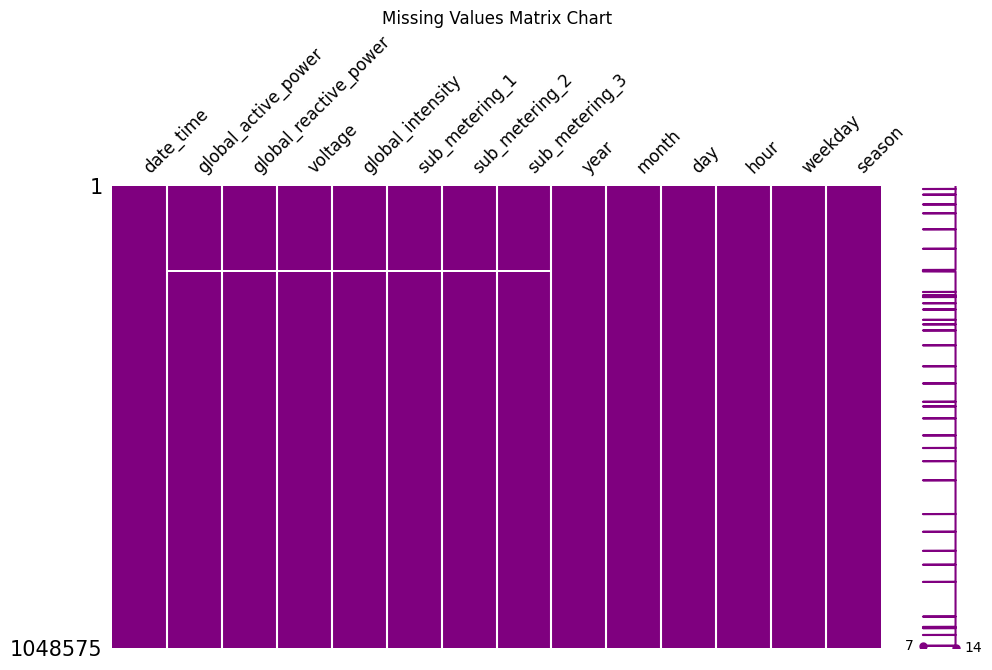

In [37]:
msno.matrix(df, 
            figsize= (11,6), 
            color= (0.5, 0, 0.5), 
            fontsize= 12)

plt.title("Missing Values Matrix Chart");

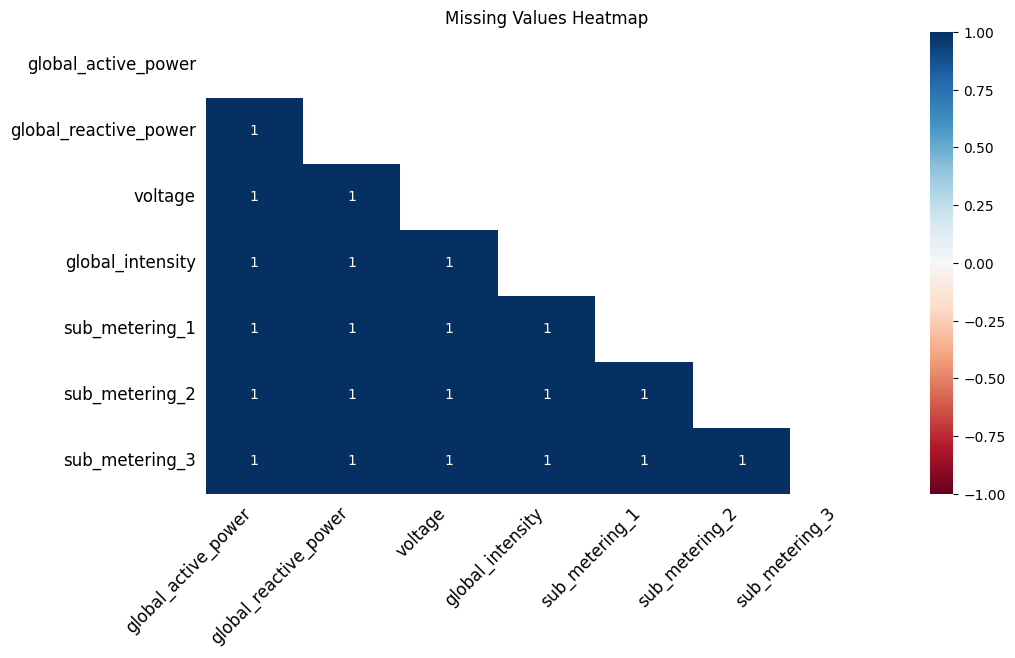

In [38]:
# Show missing values heatmap
msno.heatmap(df, 
             figsize= (11, 6), 
             fontsize= 12)

plt.title("Missing Values Heatmap");

We can see from the dataset that all pairs of variables have a correlation of $1.0$. This means that if one variable’s value is not missing, then the values of all the other variables are also not missing. In other words, the missing values (``NaN``s) always occur together in the same rows (observations).

##### Diagnosing Missing Values in `global_active_power` Based on All The Numerical Attributes 

In [39]:
def Diagnose_MV_Numerical(df, str_att_name, BM_MV):
    MV_labels = {True:'With Missing Values',
                 False:'Without Missing Values'}
    
    labels = []
    box_sr = pd.Series('', index= BM_MV.unique())    
    for poss in BM_MV.unique():
        BM = BM_MV == poss
        box_sr[poss] = df[BM][str_att_name].dropna()
        labels.append(MV_labels[poss])
    
    plt.boxplot(box_sr, vert= False)
    plt.yticks([1,2], labels)
    plt.xlabel(str_att_name)
    plt.show()
    
    plt.figure(figsize= (10,4))
    
    att_range = (df[str_att_name].min(),
                 df[str_att_name].max())

    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1, 2, i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].hist()
        plt.xlim = att_range
        plt.xlabel(str_att_name)
        plt.title(MV_labels[poss])
        plt.grid(False) 
    plt.show()
    
    group_1_data = df[BM_MV][str_att_name].dropna()
    group_2_data = df[~BM_MV][str_att_name].dropna()
    
    p_value = ttest_ind(group_1_data,group_2_data).pvalue
    
    print('p-value of t-test: {}'.format(p_value))

Diagnosis Analysis of Missing Values for global_reactive_power:


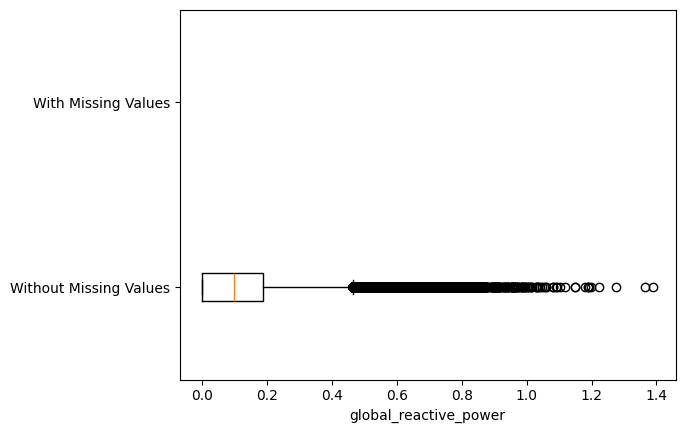

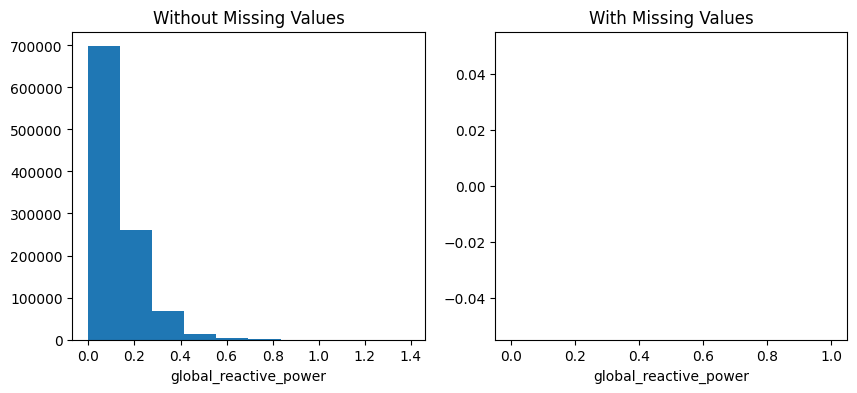

p-value of t-test: nan


Diagnosis Analysis of Missing Values for voltage:


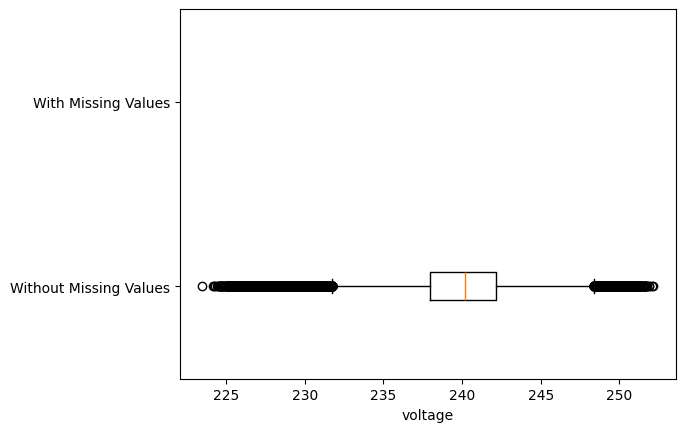

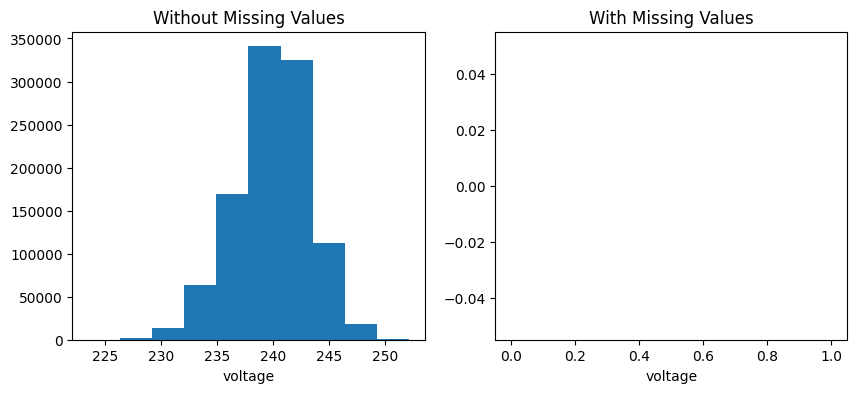

p-value of t-test: nan


Diagnosis Analysis of Missing Values for global_intensity:


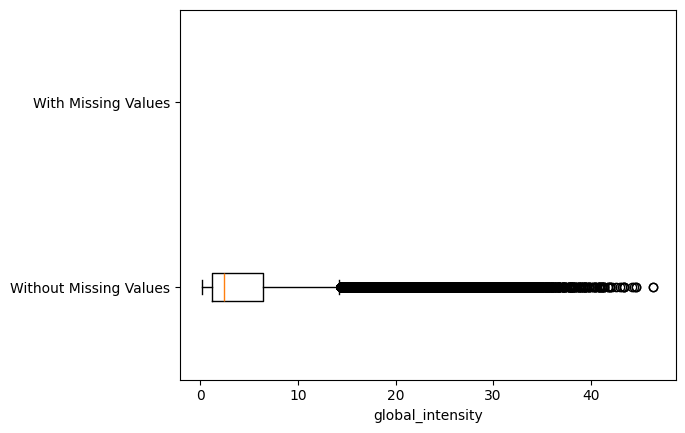

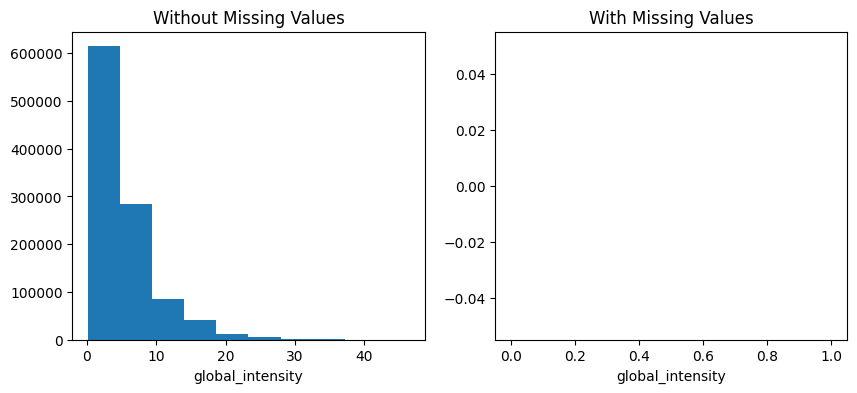

p-value of t-test: nan


Diagnosis Analysis of Missing Values for sub_metering_1:


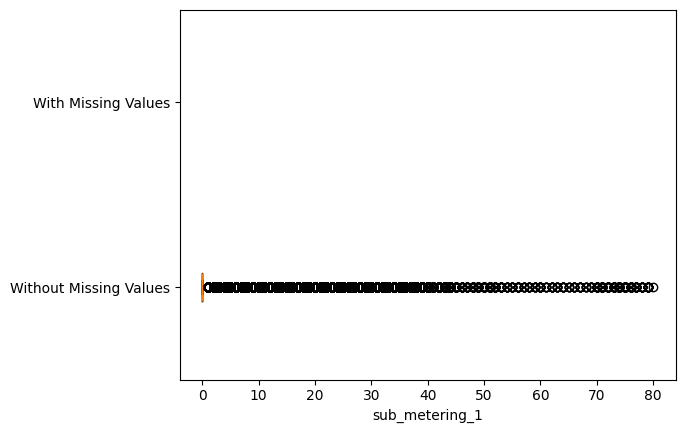

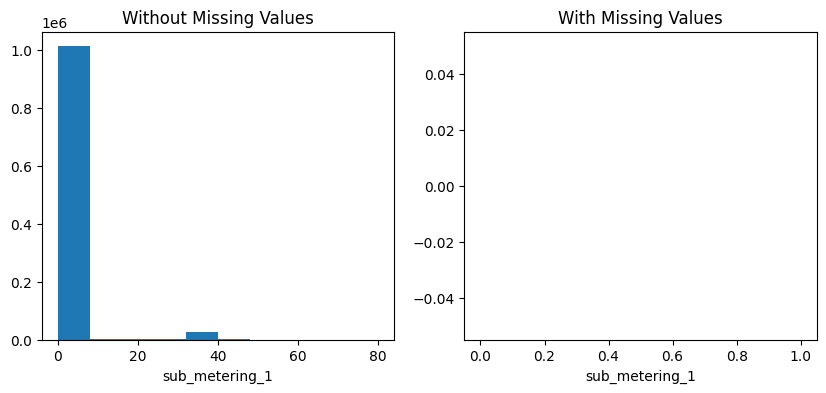

p-value of t-test: nan


Diagnosis Analysis of Missing Values for sub_metering_2:


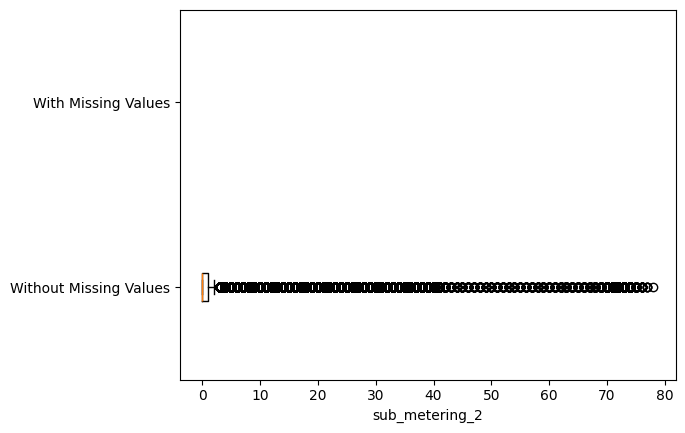

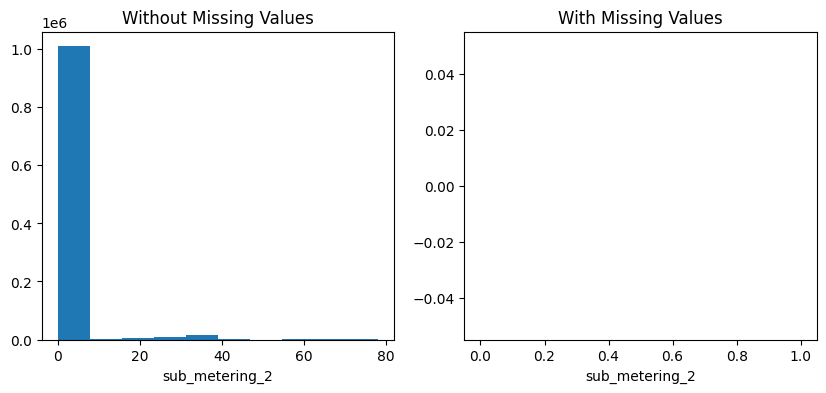

p-value of t-test: nan


Diagnosis Analysis of Missing Values for sub_metering_3:


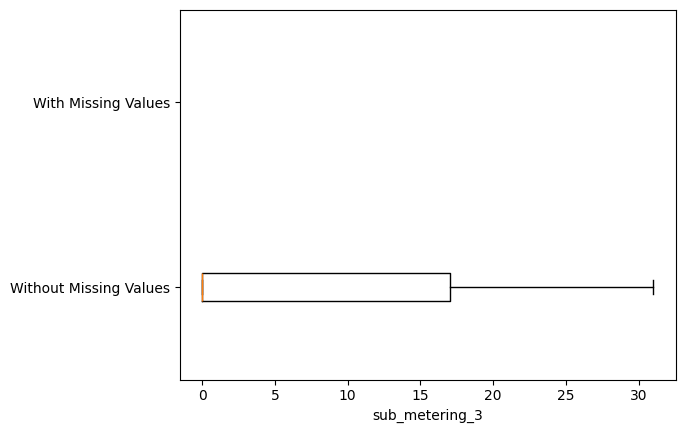

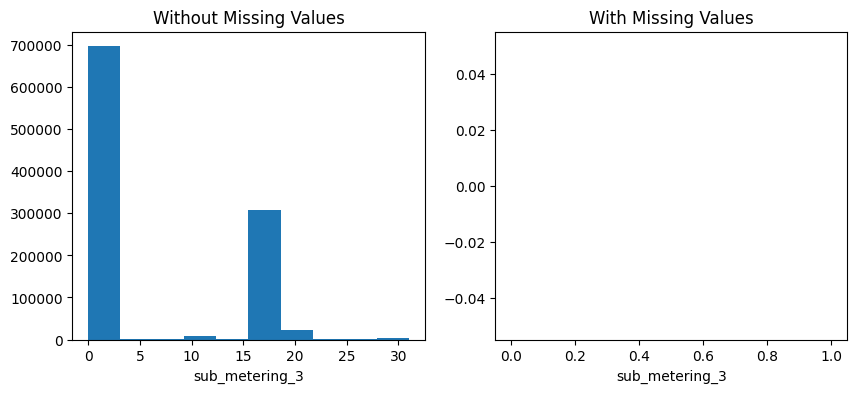

p-value of t-test: nan




In [40]:
numerical_attributes = [
    "global_reactive_power",
    "voltage",
    "global_intensity",
    "sub_metering_1",
    "sub_metering_2",
    "sub_metering_3"
]

BM_MV = df["global_active_power"].isna()
for att in numerical_attributes:
    print('Diagnosis Analysis of Missing Values for {}:'.format(att))
    Diagnose_MV_Numerical(df, att, BM_MV)
    print("\n" + "=" * 50 + "\n")

##### Diagnosing Missing Values in `global_active_power` Based on All The Categorical Attributes

In [41]:
def Diagnose_MV_Categorical(df,str_att_name,BM_MV):
    MV_labels = {True:'With Missing Values',
                 False:'Without Missing Values'}

    plt.figure(figsize=(10,4))
    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].value_counts().plot.bar()
        plt.title(MV_labels[poss])
    plt.show()

    contingency_table = pd.crosstab(BM_MV, 
                                    df[str_att_name])

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    expected_df = pd.DataFrame(expected, 
                           index= contingency_table.index, 
                           columns= contingency_table.columns)

    print("Observed Counts:")
    display(contingency_table)

    print("\nExpected Counts:")
    display(expected_df)

    print(f"\nChi2 Statistic: {chi2}")
    print(f"p-value of Chi_squared test: {p}")
    print(f"Degrees of Freedom: {dof}")

Diagnosis Analysis of Missing Values for year:


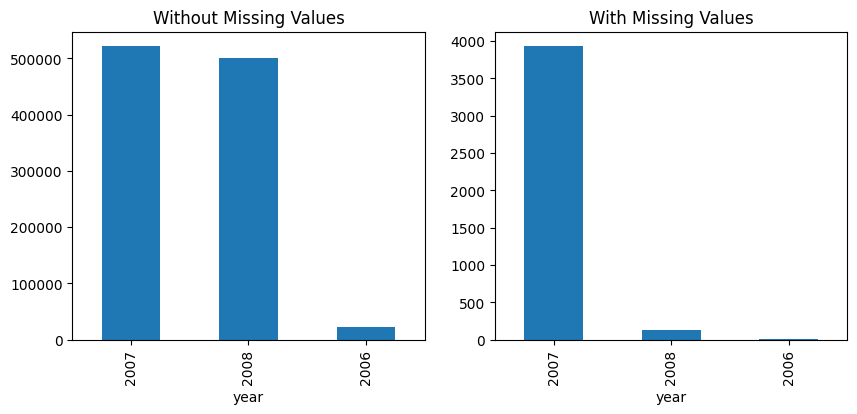

Observed Counts:


year,2006,2007,2008
global_active_power,,,
False,21992,521669,500845
True,4,3931,134



Expected Counts:


year,2006,2007,2008
global_active_power,,,
False,21910.644,523560.407,499034.949
True,85.356,2039.593,1944.051



Chi2 Statistic: 3530.517829175695
p-value of Chi_squared test: 0.0
Degrees of Freedom: 2


Diagnosis Analysis of Missing Values for month:


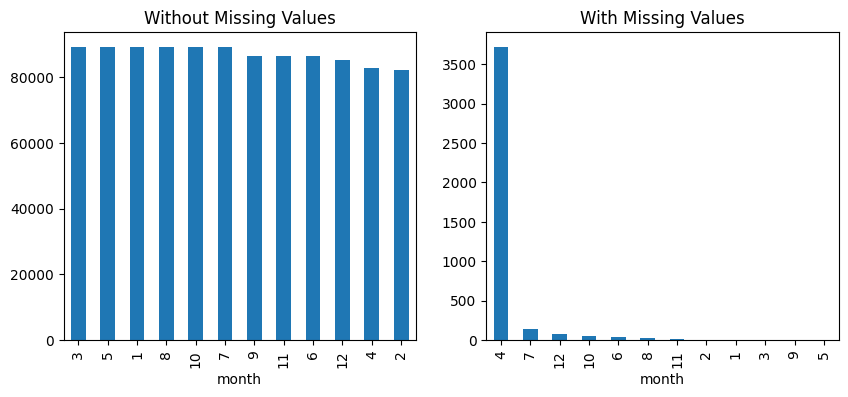

Observed Counts:


month,1,2,3,4,5,6,7,8,9,10,11,12
global_active_power,,,,,,,,,,,,
False,89277,82075,89278,82677,89278,86356,89147,89256,86398,89235,86389,85140
True,3,5,2,3723,2,44,133,24,2,45,11,75



Expected Counts:


month,1,2,3,4,5,6,7,8,9,10,11,12
global_active_power,,,,,,,,,,,,
False,88933.549,81761.488,88933.549,86064.724,88933.549,86064.724,88933.549,88933.549,86064.724,88933.549,86064.724,84884.323
True,346.451,318.512,346.451,335.276,346.451,335.276,346.451,346.451,335.276,346.451,335.276,330.677



Chi2 Statistic: 37499.669087300914
p-value of Chi_squared test: 0.0
Degrees of Freedom: 11


Diagnosis Analysis of Missing Values for day:


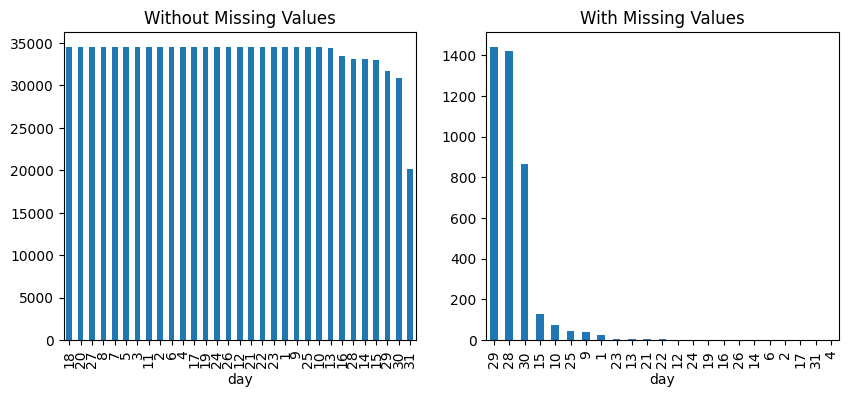

Observed Counts:


day,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
global_active_power,,,,,,,,,,,,,,,,,,,,,
False,34538,34559,34560,34559,34560,34559,34560,34560,34522,34484,...,34557,34555,34558,34516,34558,34560,33140,31678,30814,20159
True,22,1,0,1,0,1,0,0,38,76,...,3,5,2,44,2,0,1420,1442,866,1



Expected Counts:


day,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
global_active_power,,,,,,,,,,,,,,,,,,,,,
False,34425.890,34425.890,34425.890,34425.890,34425.890,34425.890,34425.890,34425.890,34425.890,34425.890,...,34425.890,34425.890,34425.890,34425.890,34425.890,34425.890,34425.890,32991.478,31557.066,20081.769
True,134.110,134.110,134.110,134.110,134.110,134.110,134.110,134.110,134.110,134.110,...,134.110,134.110,134.110,134.110,134.110,134.110,134.110,128.522,122.934,78.231



Chi2 Statistic: 33580.18697343091
p-value of Chi_squared test: 0.0
Degrees of Freedom: 30


Diagnosis Analysis of Missing Values for hour:


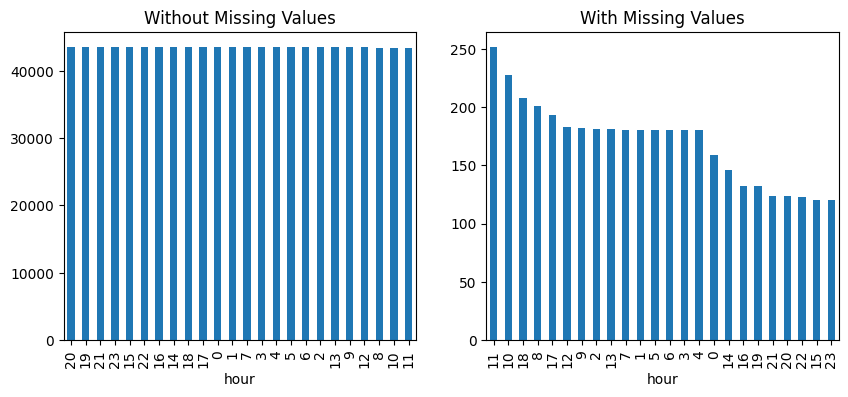

Observed Counts:


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
global_active_power,,,,,,,,,,,,,,,,,,,,,
False,43521,43500,43499,43500,43500,43500,43500,43500,43479,43498,...,43534,43560,43548,43523,43532,43608,43616,43595,43557,43560
True,159,180,181,180,180,180,180,180,201,182,...,146,120,132,193,208,132,124,124,123,120



Expected Counts:


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
global_active_power,,,,,,,,,,,,,,,,,,,,,
False,43510.500,43510.500,43510.500,43510.500,43510.500,43510.500,43510.500,43510.500,43510.500,43510.500,...,43510.500,43510.500,43510.500,43546.360,43570.267,43570.267,43570.267,43549.348,43510.500,43510.500
True,169.500,169.500,169.500,169.500,169.500,169.500,169.500,169.500,169.500,169.500,...,169.500,169.500,169.500,169.640,169.733,169.733,169.733,169.652,169.500,169.500



Chi2 Statistic: 173.04269354965152
p-value of Chi_squared test: 5.545578521577424e-25
Degrees of Freedom: 23


Diagnosis Analysis of Missing Values for weekday:


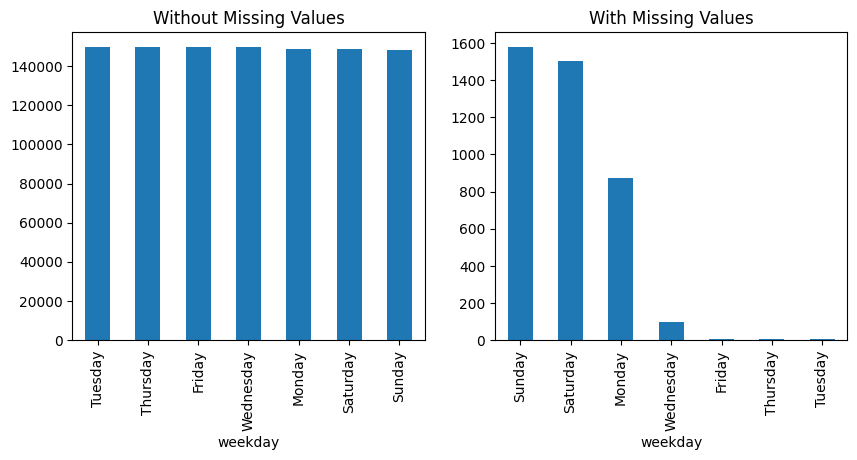

Observed Counts:


weekday,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
global_active_power,,,,,,,
False,149754,148887,148510,148181,149755,149756,149663
True,6,873,1505,1579,5,4,97



Expected Counts:


weekday,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
global_active_power,,,,,,,
False,149178.856,149178.856,149432.866,149178.856,149178.856,149178.856,149178.856
True,581.144,581.144,582.134,581.144,581.144,581.144,581.144



Chi2 Statistic: 5461.069859224541
p-value of Chi_squared test: 0.0
Degrees of Freedom: 6




In [42]:
categorical_attributes = ['year', 'month', 'day', 'hour', 'weekday']

BM_MV = df.global_active_power.isna()
for att in categorical_attributes:
    print('Diagnosis Analysis of Missing Values for {}:'.format(att))
    Diagnose_MV_Categorical(df,att,BM_MV)
    print("\n" + "=" * 50 + "\n")


The chi-square test was performed to check if missing values in the ``global_active_power`` variable depend on the day of the week. The test returned a p-value close to zero, indicating a statistically significant relationship. This means missing values are not randomly distributed across weekdays; instead, certain days have noticeably more missing data than others. Understanding this pattern can help us better handle missing values and improve our analysis.

Here’s a simple recommendation for GreenCity based on the missing data pattern:

The missing data is highly concentrated in a short time window at the end of April 2007. GreenCity should investigate this specific period for possible technical issues such as sensor failures, power outages, or maintenance.

Outside of this period, the dataset appears stable and does not show a systematic problem with missing values. Therefore, no large-scale imputation is needed, just focus on this small window.

In [43]:
# Fill na with values forward
df = df.fillna(method= 'ffill')

summarize_df(df)

Shape of df: (1048575, 14)


,Column,Dtype,Unique,NaN,percentage_missing,Examples
0,date_time,datetime64[ns],1048575,0,0.000,"[2008-12-13 21:38:00, 2006-12-16 17:24:00]"
1,global_active_power,float64,4075,0,0.000,"[0.218, 0.216]"
2,global_reactive_power,float64,491,0,0.000,"[0.0, 0.1]"
3,voltage,float64,2604,0,0.000,"[236.24, 241.18]"
4,global_intensity,float64,218,0,0.000,"[1.0, 1.4]"
5,sub_metering_1,float64,81,0,0.000,"[0.0, 1.0]"
6,sub_metering_2,float64,79,0,0.000,"[0.0, 1.0]"
7,sub_metering_3,float64,32,0,0.000,"[0.0, 18.0]"
8,year,int32,3,0,0.000,"[2007, 2008]"
9,month,int32,12,0,0.000,"[1, 3]"


---

## Exploratory Data Analysis

In [44]:
describe_df(df)

,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3,year,month,day,hour
count,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000
mean,1.106,0.119,239.947,4.710,1.173,1.470,5.913,2007.457,6.499,15.742,11.502
std,1.128,0.110,3.286,4.757,6.310,6.341,8.204,0.539,3.439,8.821,6.922
min,0.076,0.000,223.490,0.200,0.000,0.000,0.000,2006.000,1.000,1.000,0.000
25%,0.288,0.000,237.940,1.200,0.000,0.000,0.000,2007.000,4.000,8.000,6.000
50%,0.542,0.098,240.200,2.400,0.000,0.000,0.000,2007.000,7.000,16.000,12.000
75%,1.542,0.188,242.140,6.400,0.000,1.000,17.000,2008.000,9.000,23.000,18.000
max,10.670,1.390,252.140,46.400,80.000,78.000,31.000,2008.000,12.000,31.000,23.000
range,10.594,1.390,28.650,46.200,80.000,78.000,31.000,2.000,11.000,30.000,23.000
IQR,1.254,0.188,4.200,5.200,0.000,1.000,17.000,1.000,5.000,15.000,12.000


### Summarizing Numerical Attributes

In [45]:
numerical_attributes = ['global_active_power',
                        'sub_metering_1',
                        'sub_metering_2',
                        'sub_metering_3']

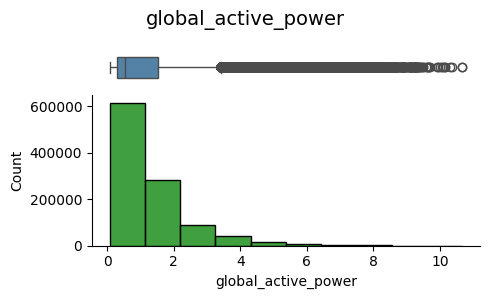

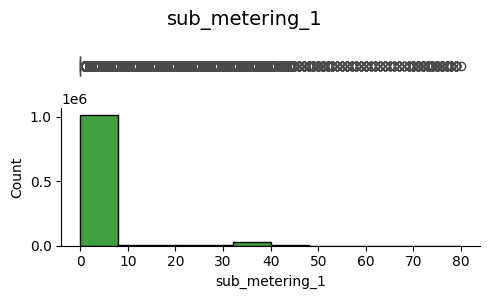

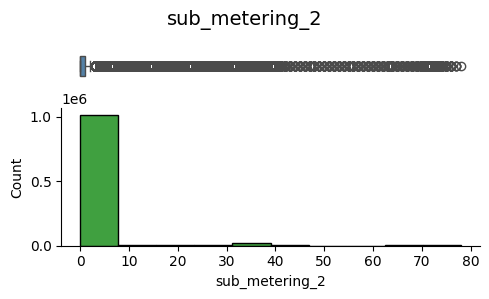

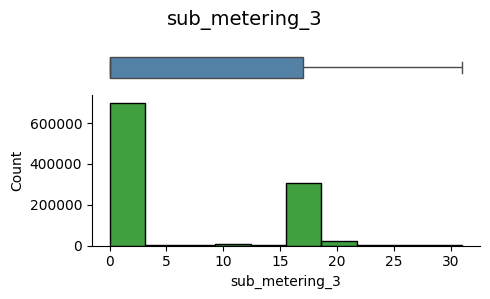

In [46]:
for att in numerical_attributes:
    fig, (ax_box, ax_hist) = plt.subplots(
        2, 
        sharex= True,
        gridspec_kw= {"height_ratios": (.15, .85)},
        figsize= (5,3)
    )

    # --- Boxplot on top ---
    sns.boxplot(
                x= df[att], 
                ax= ax_box, 
                color= "steelblue"
                )
    ax_box.set_axis_off()   # hide axis so only histogram axis is visible

    # --- Histogram below ---
    sns.histplot(
                 x= df[att], 
                 bins= 10, 
                 kde= False, 
                 color="green", 
                 ax= ax_hist
                 )
    ax_hist.set_xlabel(att)
    ax_hist.grid(False)

    sns.despine(ax= ax_hist)
    fig.suptitle(f"{att}", fontsize= 14)
    plt.tight_layout()
    # plt.savefig(f"{att}.png", dpi=600)
    plt.show()

### Summarizing Categorical Attributes

In [47]:
categorical_attributes = []

In [48]:
for att in categorical_attributes:
    # Compute counts
    counts = df[att].value_counts().reset_index()
    counts.columns = [att, "count"]

    # Plot 
    plt.figure(figsize=(6,4))
    ax = sns.barplot(
        data= counts,
        x= "count",
        y= att,
        color= "steelblue"
    )

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, 
                     fmt= "%d", 
                     # Place labels at the top edge
                     label_type= "edge", 
                     fontsize= 10,
                     fontweight= "bold", 
                     # Push the label into the bar
                     # padding= -20,
                     color= 'black')
    
    # Titles and layout
    ax.set_title(att)
    plt.tight_layout()
    # plt.savefig(f"{att}.png", dpi=600)
    plt.show()

### Analysis Question 1: How does average global active power consumption vary by season?

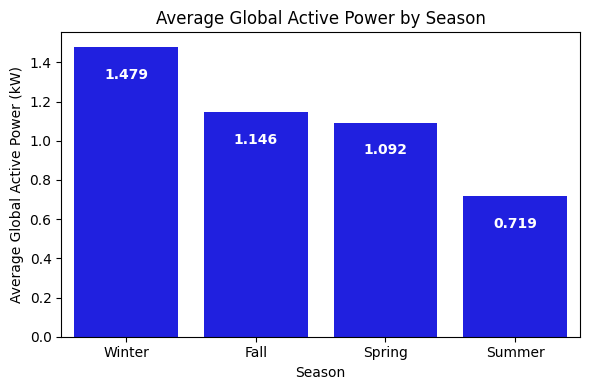

In [49]:
# Group by season and calculate average 
seasonal_data = df.groupby('season')['global_active_power'].mean()\
                .reset_index()\
                .sort_values(by= 'global_active_power', 
                             ascending= False)

plt.figure(figsize=(6, 4))
ax = sns.barplot(data= seasonal_data,
                 x= "season",
                 y= "global_active_power",
                 color= "blue")

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, 
                 fmt= "%.3f", 
                 # Place labels at the top edge
                 label_type= "edge", 
                 fontsize= 10,
                 fontweight= "bold", 
                 # Push the label into the bar
                 padding= -25,
                 color= 'white')

# Titles and labels
ax.set_title("Average Global Active Power by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Average Global Active Power (kW)")

plt.tight_layout()
plt.show()

The analysis of seasonal electricity consumption shows clear variation across the year. Winter exhibits the highest average global active power usage at 1.479 kW, likely due to increased heating and lighting needs. In contrast, Summer records the lowest average consumption at 0.719 kW, suggesting lower demand during warmer months. Spring and Fall show moderate consumption levels at 1.092 kW and 1.146 kW respectively. These patterns indicate a seasonal trend in energy usage, with higher consumption in colder seasons and lower in warmer ones.

---

### AQ 2: Is there a significant difference in average electricity consumption between the Kitchen, Laundry Room, and Water Heater & AC?

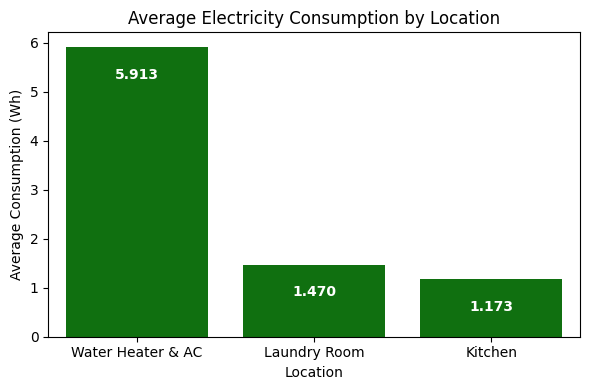

In [50]:
# Step 1: Select sub-metering columns
metering_df = df[["sub_metering_1", 
                  "sub_metering_2", 
                  "sub_metering_3"]]

# Step 2: Reshape to long format
metering_long = metering_df.melt(var_name= "sub_metering", 
                                 value_name= "consumption")

# Step 3: Map to readable names
name_map = {
    "sub_metering_1": "Kitchen",
    "sub_metering_2": "Laundry Room",
    "sub_metering_3": "Water Heater & AC"
}
metering_long["location"] = metering_long["sub_metering"].map(name_map)

# Step 4: Compute average consumption per location
avg_consumption = metering_long.groupby("location")["consumption"].mean()\
                  .reset_index()\
                  .sort_values(by= 'consumption',
                               ascending= False)

# Step 5: Plot
plt.figure(figsize=(6,4))
ax = sns.barplot(data= avg_consumption,
                 x= "location",
                 y= "consumption",
                 color= "green")

# Step 6: Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, 
                 fmt= "%.3f", 
                 # Place labels at the top edge
                 label_type= "edge", 
                 fontsize= 10,
                 fontweight= "bold", 
                 # Push the label into the bar
                 padding= -25,
                 color= 'white')


# Step 7: Titles and labels
ax.set_title("Average Electricity Consumption by Location")
ax.set_xlabel("Location")
ax.set_ylabel("Average Consumption (Wh)")

plt.grid(False)
plt.tight_layout()
plt.show()

The analysis of average electricity consumption across different household locations reveals a clear difference in usage patterns. The Water Heater & AC shows the highest average consumption at 5.91 Wh, which is significantly higher than both the Laundry Room (1.47 Wh) and the Kitchen (1.17 Wh). This indicates that the Water Heater & AC devices are the major contributors to electricity usage in the home, while the Laundry Room and Kitchen consume substantially less power on average. These insights can help target energy-saving measures more effectively.

A short recommendation:
- The Water Heater & AC (5.9 Wh) consume the most electricity. GreenCity should check if these devices are running efficiently or consider upgrading to more energy-efficient models.
- In the Laundry Room (1.47 Wh) and Kitchen (1.17 Wh), using energy-efficient washers and dryers could help reduce this consumption.

### Trend

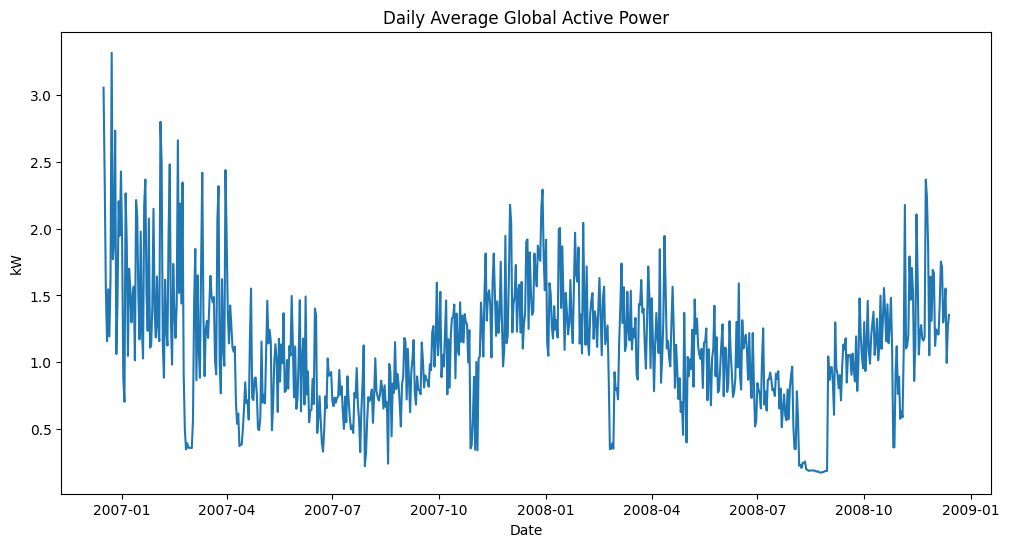

In [51]:
df_daily = df.resample('D', on='date_time')['global_active_power'].mean()

plt.figure(figsize=(12,6))
plt.plot(df_daily.index, df_daily.values)
plt.title("Daily Average Global Active Power")
plt.xlabel("Date")
plt.ylabel("kW")
plt.show()

<Axes: xlabel='date_time'>

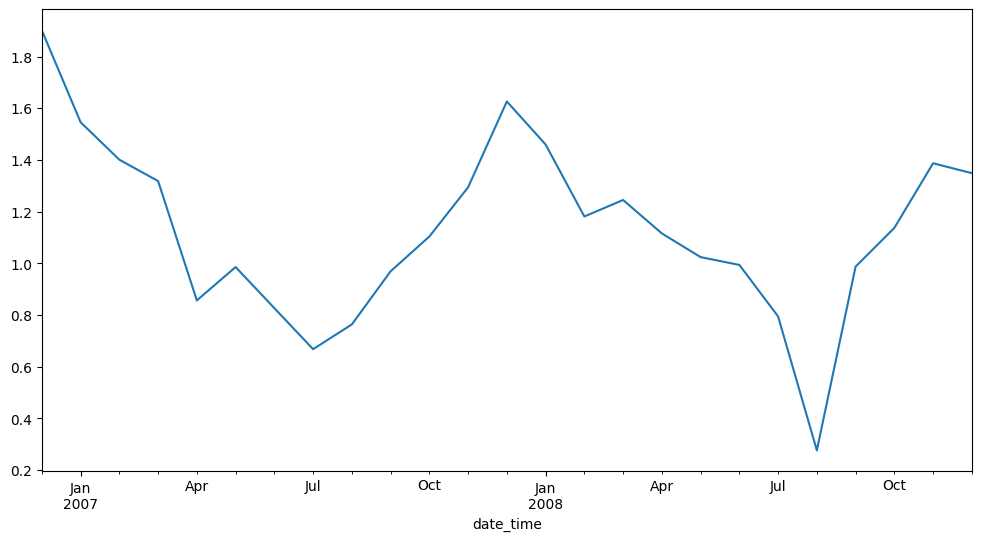

In [52]:
df_monthly = df.resample('M', on='date_time')['global_active_power'].mean()

df_monthly.plot(figsize=(12,6))

---

## Modeling

### Scaling

In [53]:
# Identify numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Exclude columns we don't want to scale
exclude = ['year', 'month', 'day', 'hour', 'minute', 'weekday']  # extend if needed
scale_cols = [col for col in numeric_cols if col not in exclude]

describe_df(df, scale_cols)

,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3
count,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000
mean,1.106,0.119,239.947,4.710,1.173,1.470,5.913
std,1.128,0.110,3.286,4.757,6.310,6.341,8.204
min,0.076,0.000,223.490,0.200,0.000,0.000,0.000
25%,0.288,0.000,237.940,1.200,0.000,0.000,0.000
50%,0.542,0.098,240.200,2.400,0.000,0.000,0.000
75%,1.542,0.188,242.140,6.400,0.000,1.000,17.000
max,10.670,1.390,252.140,46.400,80.000,78.000,31.000
range,10.594,1.390,28.650,46.200,80.000,78.000,31.000
IQR,1.254,0.188,4.200,5.200,0.000,1.000,17.000


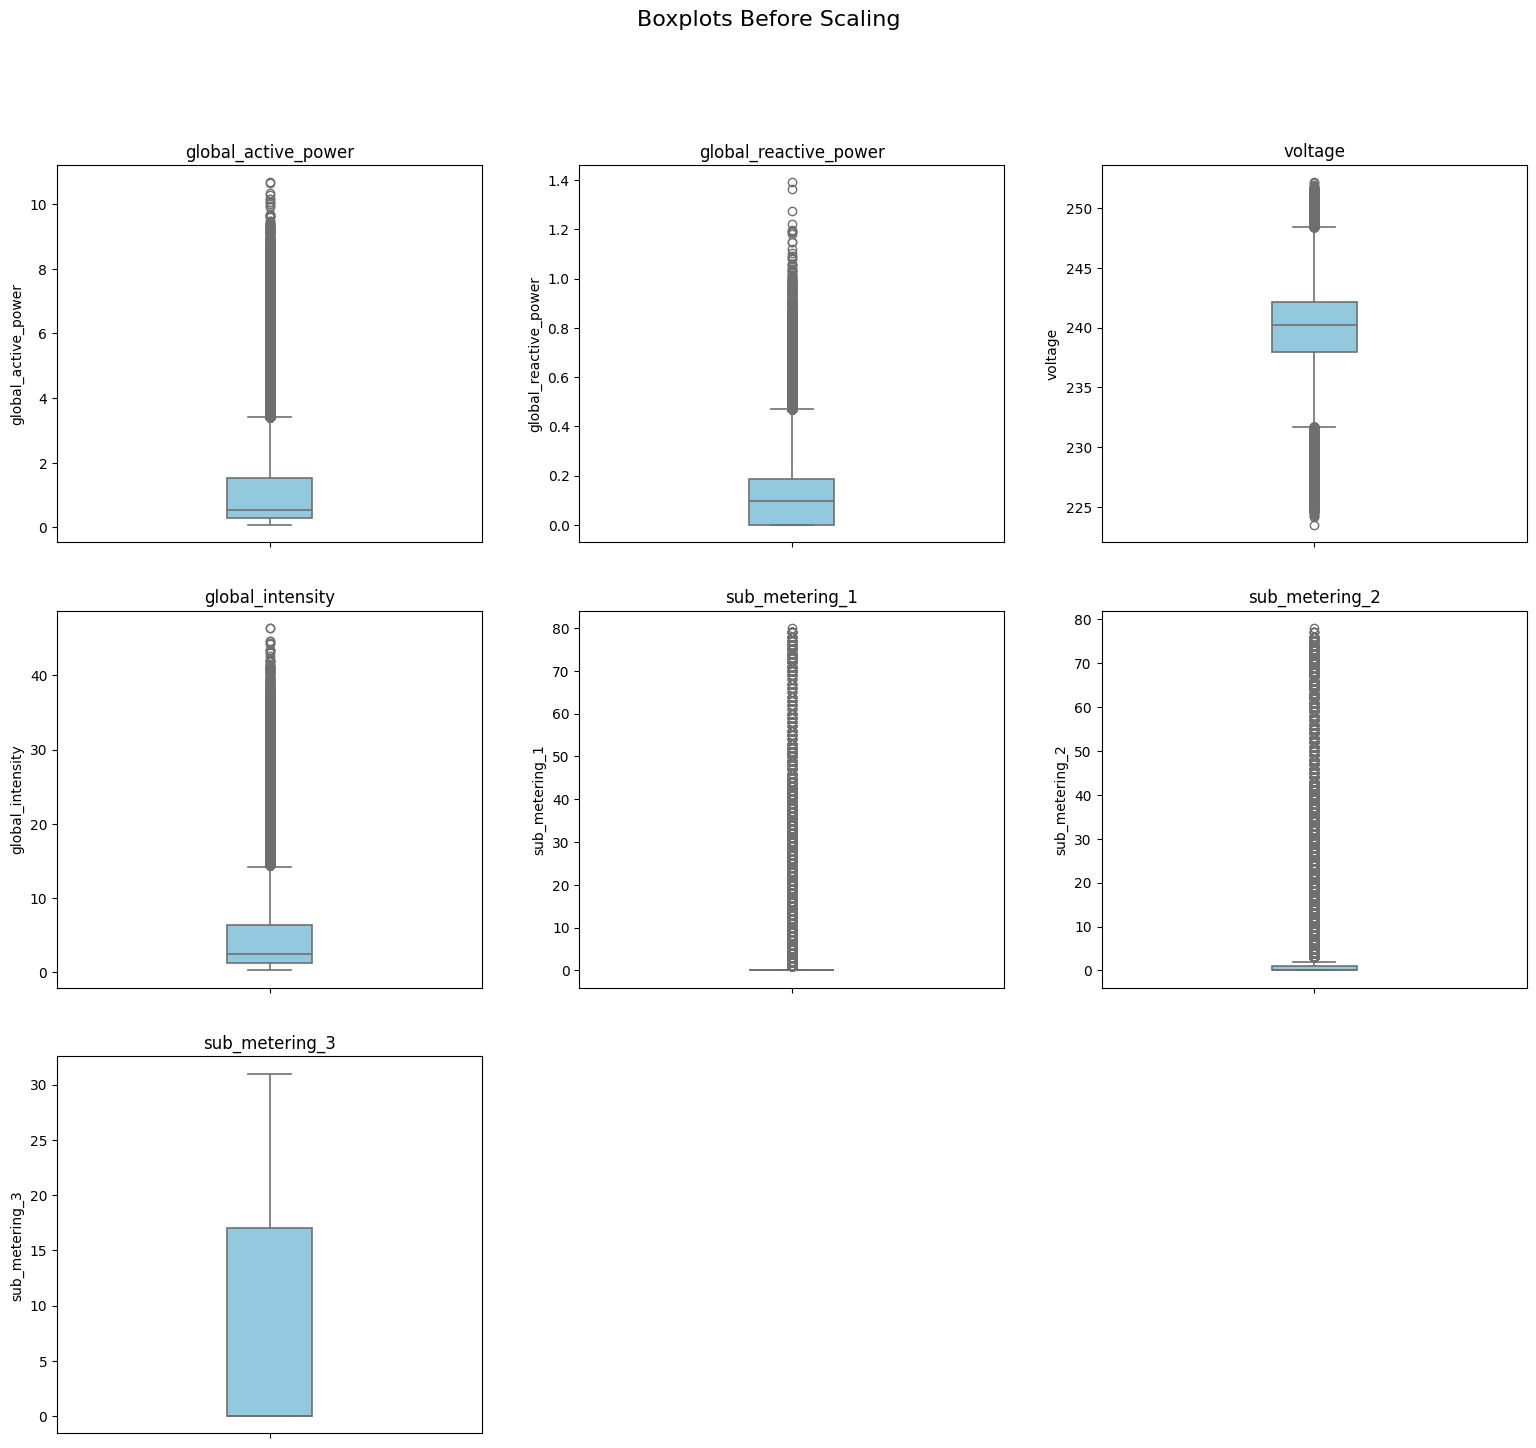

In [54]:
# Number of variables to scale
num_vars = len(scale_cols)

# Calculate rows and columns for subplots
cols = 3  # 3 plots per row
rows = (num_vars + cols - 1) // cols

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))

for i, col in enumerate(scale_cols):
    ax = axes[i // cols, i % cols]
    
    # Seaborn boxplot for each column
    sns.boxplot(
        y=df[col].dropna(), 
        ax= ax, 
        color= "skyblue", 
        width= 0.2,    # make boxes thinner if desired
        linewidth= 1.2 # control edge thickness
    )
    
    ax.set_title(col)
    ax.grid(False)

# Turn off empty subplots if any
for j in range(i + 1, rows * cols):
    fig.delaxes(axes[j // cols, j % cols])

# Add main title
fig.suptitle("Boxplots Before Scaling", fontsize=16)

# Adjust layout to fit title and avoid overlap
plt.tight_layout(rect=[0, 0, 1, 0.96], pad= 3.0)  
plt.show()


| Variable                  | Scaler Used    | Reason                                      |
|---------------------------|---------------|---------------------------------------------|
| `global_active_power` etc. | RobustScaler  | Presence of outliers → median & IQR are robust |
| `sub_metering_1`, `sub_metering_2` | StandardScaler | IQR too small → mean & std provide better scaling |
| `sub_metering_3` | StandardScaler | There are no outliers.|


In [55]:
# Define columns
robust_cols = ['global_active_power', 
               'global_reactive_power', 
               'voltage', 
               'global_intensity']  # for Robust Scaler

standard_cols = ['sub_metering_1',
                 'sub_metering_2',
                 'sub_metering_3']  # for Standard Scaler

# Apply RobustScaler
rs = RobustScaler()
df[robust_cols] = rs.fit_transform(df[robust_cols])

# Apply StandardScaler
ss = StandardScaler()
df[standard_cols] = ss.fit_transform(df[standard_cols])

# Save both scalers
joblib.dump(rs, "robust_scaler.pkl")
joblib.dump(ss, "standard_scaler.pkl")

['standard_scaler.pkl']

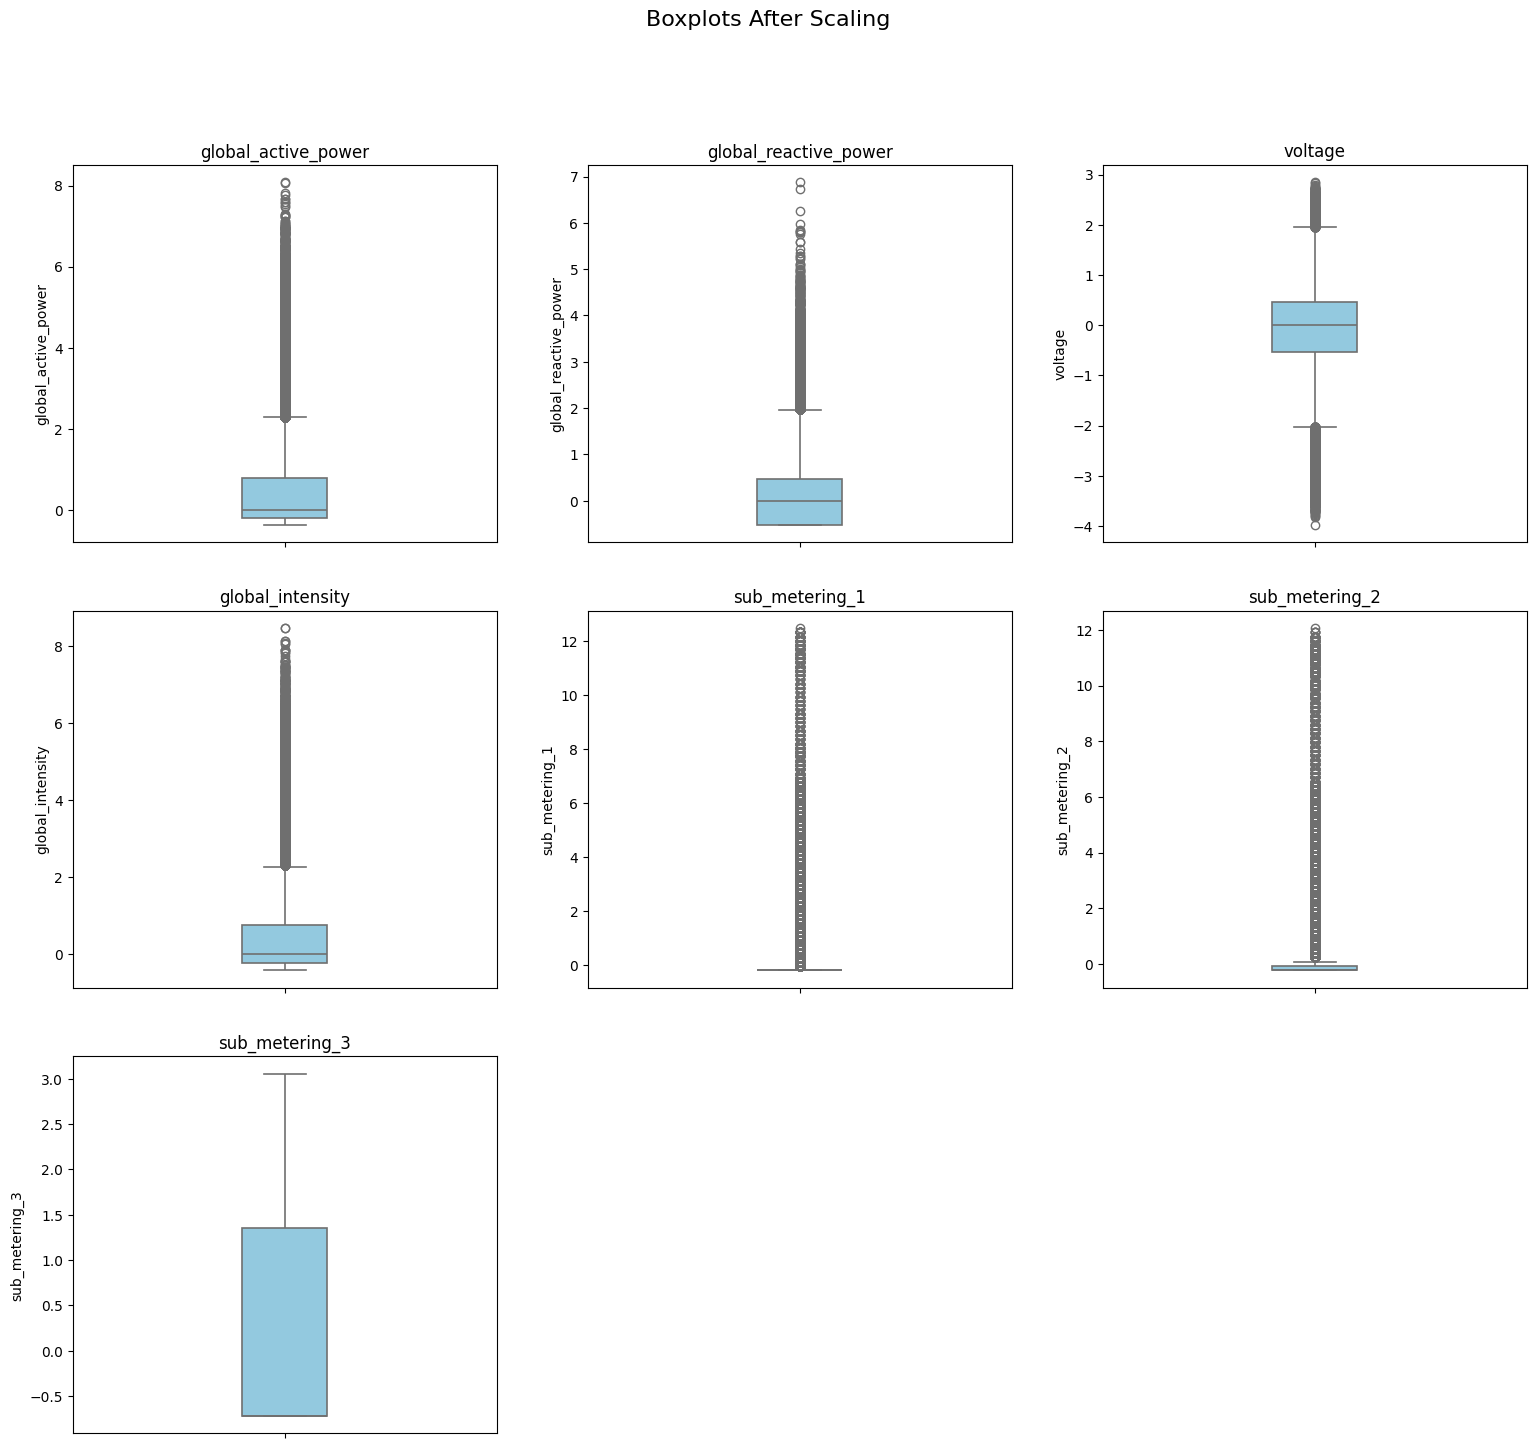

In [56]:
scaled_cols = robust_cols + standard_cols

# Number of variables to scale
num_vars = len(scaled_cols)

# Calculate rows and columns for subplots
cols = 3  # 3 plots per row
rows = (num_vars + cols - 1) // cols

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))

for i, col in enumerate(scaled_cols):
    ax = axes[i // cols, i % cols]
    
    # Seaborn boxplot for each column
    sns.boxplot(
        y= df[col].dropna(), 
        ax= ax, 
        color= "skyblue", 
        width= 0.2,    # make boxes thinner if desired
        linewidth= 1.2 # control edge thickness
    )
    
    ax.set_title(col)
    ax.grid(False)

# Turn off empty subplots if any
for j in range(i + 1, rows * cols):
    fig.delaxes(axes[j // cols, j % cols])

# Add main title
fig.suptitle("Boxplots After Scaling", fontsize= 16)

# Adjust layout to fit title and avoid overlap
plt.tight_layout(rect=[0, 0, 1, 0.96], pad= 3.0)  
plt.show()


In [57]:
describe_df(df, scaled_cols)

,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3
count,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000
mean,0.450,0.110,-0.060,0.444,-0.000,-0.000,-0.000
std,0.900,0.583,0.782,0.915,1.000,1.000,1.000
min,-0.372,-0.521,-3.979,-0.423,-0.186,-0.232,-0.721
25%,-0.203,-0.521,-0.538,-0.231,-0.186,-0.232,-0.721
50%,0.000,0.000,0.000,0.000,-0.186,-0.232,-0.721
75%,0.797,0.479,0.462,0.769,-0.186,-0.074,1.351
max,8.077,6.872,2.843,8.462,12.493,12.069,3.058
range,8.448,7.394,6.821,8.885,12.679,12.301,3.779
IQR,1.000,1.000,1.000,1.000,0.000,0.158,2.072


---

### Train-Validation-Test Split

In [58]:
# Sort dataframe by datetime 
df = df.sort_values('date_time')

# Compute the 90% quantiles of the datetime index
train_end = df['date_time'].quantile(0.8)
val_end   = df['date_time'].quantile(0.9)

# Train = 0% to 80%
train_df = df[df['date_time'] <= train_end]

# Validation = 80% to 90%
val_df = df[(df['date_time'] > train_end) & (df['date_time'] <= val_end)]

# Test = 90% to 100%
test_df = df[df['date_time'] > val_end]

# Print row counts
print(f"The number of the training data rows: {len(train_df)}")
print(f"The number of the validation rows: {len(val_df)}")
print(f"The number of the test rows: {len(test_df)}")

The number of the training data rows: 838860
The number of the validation rows: 104857
The number of the test rows: 104858


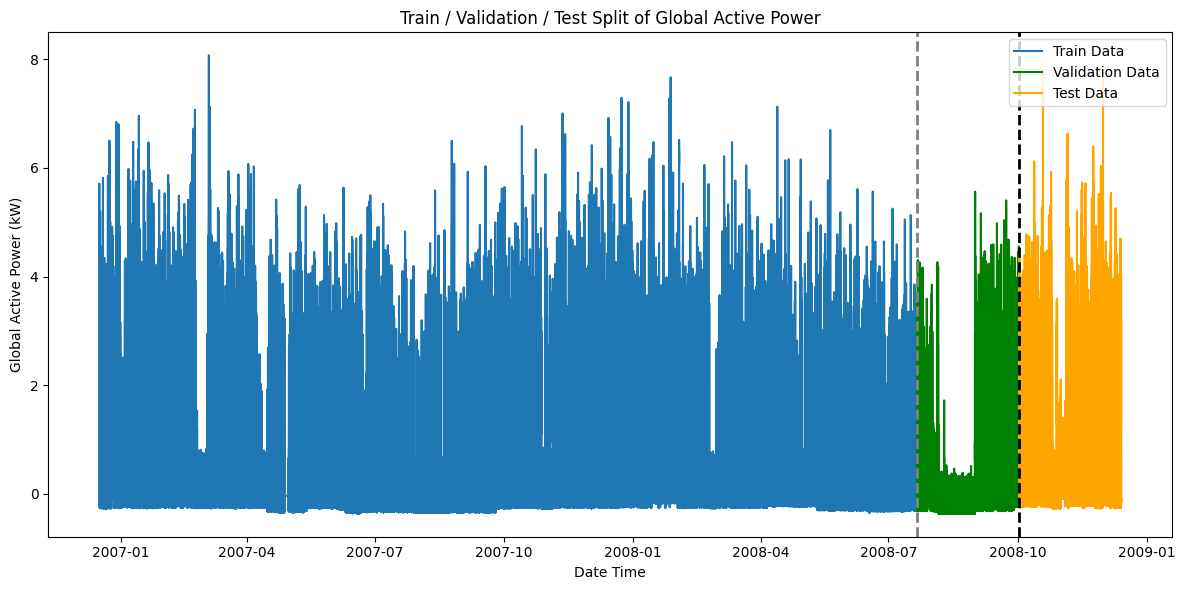

In [59]:
plt.figure(figsize=(12, 6))

# Plot train
plt.plot(train_df['date_time'], 
         train_df['global_active_power'], 
         label='Train Data')

# Plot validation
plt.plot(val_df['date_time'], 
         val_df['global_active_power'], 
         label='Validation Data', 
         color='green')

# Plot test
plt.plot(test_df['date_time'], 
         test_df['global_active_power'], 
         label='Test Data', 
         color='orange')

# Vertical lines for splits
plt.axvline(x=train_end, 
            color='grey', 
            linestyle='--', 
            linewidth=2)

plt.axvline(x=val_end, 
            color='black', 
            linestyle='--', 
            linewidth=2)

# Labels and legend
plt.title('Train / Validation / Test Split of Global Active Power')
plt.xlabel('Date Time')
plt.ylabel('Global Active Power (kW)')
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

---

### Train Models

In [36]:
# Separate features and target
features = ['sub_metering_1', 
            'sub_metering_2', 
            'sub_metering_3']
target = 'global_active_power'

# Prepare X and y for each split
X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

#### Linear Regression

In [39]:
# Train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on train and validation
y_train_pred = lr.predict(X_train)
y_val_pred   = lr.predict(X_val)

# Evaluate using the helper function
lr_results = evaluate_model(
    model_name= "Linear Regression",
    y_train= y_train,
    y_train_pred= y_train_pred,
    y_val= y_val,
    y_val_pred= y_val_pred
)

# Append to global error_df
error_df = pd.concat([error_df, lr_results], ignore_index=True)

error_df

,Model,Train RMSE,Val RMSE,overfit_score,diagnosis
0,Linear Regression,0.510,0.370,0.726,Underfitting


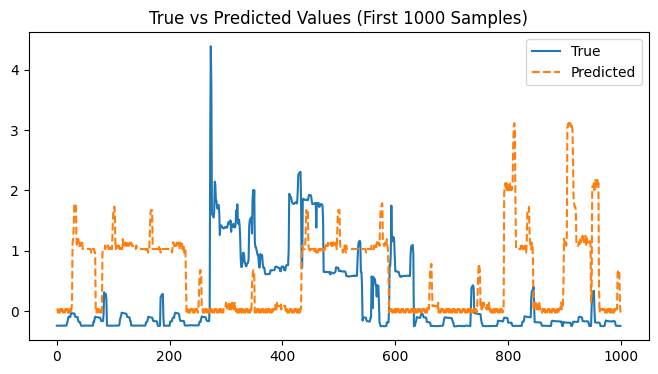

In [40]:
plt.figure(figsize= (8, 4))
plt.plot(y_test.values[:1000], label= 'True')
plt.plot(y_val_pred[:1000], 
         label= 'Predicted', 
         linestyle= '--')
plt.title('True vs Predicted Values (First 1000 Samples)')
plt.legend()
plt.show()

#### Polynomial Regression

In [41]:
# Degree of the polynomial
DEGREE = 2

# Create polynomial features transformer
poly = PolynomialFeatures(degree=DEGREE, include_bias=False)

# Transform train and validation features
X_train_poly = poly.fit_transform(X_train)
X_val_poly   = poly.transform(X_val)

# Train linear regression on polynomial features
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

# Predict on train and validation
y_train_pred = lr_poly.predict(X_train_poly)
y_val_pred   = lr_poly.predict(X_val_poly)

# Evaluate using the helper function
poly_results = evaluate_model(
    model_name=f"Polynomial Regression (degree={DEGREE})",
    y_train=y_train,
    y_train_pred=y_train_pred,
    y_val=y_val,
    y_val_pred=y_val_pred
)

# Append to global error_df
error_df = pd.concat([error_df, poly_results], ignore_index=True)

error_df

,Model,Train RMSE,Val RMSE,overfit_score,diagnosis
0,Linear Regression,0.510,0.370,0.726,Underfitting
1,Polynomial Regression (degree=2),0.508,0.378,0.744,Underfitting


#### Decision Tree Regression

In [42]:
# Train the Decision Tree Regressor
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

# Predict on train and validation
y_train_pred = tree.predict(X_train)
y_val_pred   = tree.predict(X_val)

# Evaluate using your helper function
tree_results = evaluate_model(
    model_name="Decision Tree Regression",
    y_train=y_train,
    y_train_pred=y_train_pred,
    y_val=y_val,
    y_val_pred=y_val_pred
)

# Append to global error_df
error_df = pd.concat([error_df, tree_results], ignore_index=True)

error_df

,Model,Train RMSE,Val RMSE,overfit_score,diagnosis
0,Linear Regression,0.510,0.370,0.726,Underfitting
1,Polynomial Regression (degree=2),0.508,0.378,0.744,Underfitting
2,Decision Tree Regression,0.497,0.323,0.650,Underfitting


---

#### Random Forest Regression

In [43]:
# Train the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Predict on train and validation
y_train_pred = rf.predict(X_train)
y_val_pred   = rf.predict(X_val)

# Evaluate using your helper function
rf_results = evaluate_model(
    model_name= "Random Forest Regression",
    y_train= y_train,
    y_train_pred= y_train_pred,
    y_val= y_val,
    y_val_pred= y_val_pred
)

# Append to global error_df
error_df = pd.concat([error_df, rf_results], ignore_index=True)

error_df


,Model,Train RMSE,Val RMSE,overfit_score,diagnosis
0,Linear Regression,0.510,0.370,0.726,Underfitting
1,Polynomial Regression (degree=2),0.508,0.378,0.744,Underfitting
2,Decision Tree Regression,0.497,0.323,0.650,Underfitting
3,Random Forest Regression,0.497,0.322,0.648,Underfitting


---

#### Gradient Boosting Regression

In [44]:
# Record the starting time
start = time.time()

# Train Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

# Predict on train and validation
y_train_pred = gbr.predict(X_train)
y_val_pred   = gbr.predict(X_val)

# Evaluate using your helper function
gbr_results = evaluate_model(
    model_name="Gradient Boosting Regression",
    y_train=y_train,
    y_train_pred=y_train_pred,
    y_val=y_val,
    y_val_pred=y_val_pred
)

# Append to global error_df
error_df = pd.concat([error_df, gbr_results], ignore_index=True)

# Calculate and print the elapsed time
end = time.time()
print(f"Elapsed time: {end - start:.2f} seconds")

error_df

Elapsed time: 10.04 seconds


,Model,Train RMSE,Val RMSE,overfit_score,diagnosis
0,Linear Regression,0.510,0.370,0.726,Underfitting
1,Polynomial Regression (degree=2),0.508,0.378,0.744,Underfitting
2,Decision Tree Regression,0.497,0.323,0.650,Underfitting
3,Random Forest Regression,0.497,0.322,0.648,Underfitting
4,Gradient Boosting Regression,0.499,0.322,0.646,Underfitting


---

##### CatBoost 

In [45]:
start = time.time()

# Initialize CatBoost model
cat_model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=0  # suppress output
)

# Train
cat_model.fit(X_train, y_train)

# Predict on train and validation
y_train_pred = cat_model.predict(X_train)
y_val_pred   = cat_model.predict(X_val)

# Evaluate using your helper function
cat_results = evaluate_model(
    model_name="CatBoost Regression",
    y_train=y_train,
    y_train_pred=y_train_pred,
    y_val=y_val,
    y_val_pred=y_val_pred
)

# Append to global error_df
error_df = pd.concat([error_df, cat_results], ignore_index=True)

# Calculate and print the elapsed time
end = time.time()
print(f"Elapsed time: {end - start:.2f} seconds")

error_df

Elapsed time: 3.84 seconds


,Model,Train RMSE,Val RMSE,overfit_score,diagnosis
0,Linear Regression,0.510,0.370,0.726,Underfitting
1,Polynomial Regression (degree=2),0.508,0.378,0.744,Underfitting
2,Decision Tree Regression,0.497,0.323,0.650,Underfitting
3,Random Forest Regression,0.497,0.322,0.648,Underfitting
4,Gradient Boosting Regression,0.499,0.322,0.646,Underfitting
5,CatBoost Regression,0.499,0.323,0.647,Underfitting


---

##### XGBoost

In [46]:
start = time.time()

# Train the model
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict on train and validation
y_train_pred = xgb_model.predict(X_train)
y_val_pred   = xgb_model.predict(X_val)

# Evaluate using your helper function
xgb_results = evaluate_model(
    model_name="XGBoost Regression",
    y_train=y_train,
    y_train_pred=y_train_pred,
    y_val=y_val,
    y_val_pred=y_val_pred
)

# Append to global error_df
error_df = pd.concat([error_df, xgb_results], ignore_index=True)

# Calculate and print the elapsed time
end = time.time()
print(f"Elapsed time: {end - start:.2f} seconds")

error_df

Elapsed time: 0.80 seconds


,Model,Train RMSE,Val RMSE,overfit_score,diagnosis
0,Linear Regression,0.510,0.370,0.726,Underfitting
1,Polynomial Regression (degree=2),0.508,0.378,0.744,Underfitting
2,Decision Tree Regression,0.497,0.323,0.650,Underfitting
3,Random Forest Regression,0.497,0.322,0.648,Underfitting
4,Gradient Boosting Regression,0.499,0.322,0.646,Underfitting
5,CatBoost Regression,0.499,0.323,0.647,Underfitting
6,XGBoost Regression,0.499,0.322,0.646,Underfitting


---

#### Linear Support Vector Regression

In [ ]:
start = time.time()

# Define and train the model
svr_model = LinearSVR(
    epsilon=0.1,
    C=1.0,
    random_state=42,
    max_iter=1000
)
svr_model.fit(X_train, y_train)

# Predict on train and validation
y_train_pred = svr_model.predict(X_train)
y_val_pred   = svr_model.predict(X_val)

# Evaluate using your helper function
svr_results = evaluate_model(
    model_name="LinearSVR",
    y_train=y_train,
    y_train_pred=y_train_pred,
    y_val=y_val,
    y_val_pred=y_val_pred
)

# Append to global error_df
error_df = pd.concat([error_df, svr_results], ignore_index=True)

# Calculate and print the elapsed time
end = time.time()
print(f"Elapsed time: {end - start:.2f} seconds")

error_df

---

#### ARIMA

In [61]:
# Prepare time series for ARIMA
ts_train = train_df.set_index('date_time')['global_active_power']
ts_val   = val_df.set_index('date_time')['global_active_power']
ts_test  = test_df.set_index('date_time')['global_active_power']

##### Augmented Dickey-Fuller (ADF) Test for Stationarity  

````py
adfuller(ts_train)



---------------------------------------------------------------------------
MemoryError                               Traceback (most recent call last)
Cell In[66], line 3
      1 from statsmodels.tsa.stattools import adfuller
----> 3 adfuller(ts_train)

MemoryError: Unable to allocate 659. MiB for an array with shape (103, 838744) and data type float64

In [ ]:
ts_train_5min = ts_train.resample('5min').mean()

adfuller(ts_train_5min)

(np.float64(-44.09942749555249),
 0.0,
 46,
 167726,
 {'1%': np.float64(-3.430388988589024),
  '5%': np.float64(-2.8615572324221947),
  '10%': np.float64(-2.5667791722019695)},
 np.float64(110492.75684317201))

**ADF Statistic:** -44.099  
**p-value:** 0.0  

**Critical Values:**  
- **1%:** -3.430  
- **5%:** -2.861  
- **10%:** -2.566  

The 5‑minute resampled series is **stationary**:
- The ADF statistic (-44.099) is *far* below all critical values.  
- The p‑value is 0.0, meaning we reject the null hypothesis of non‑stationarity.

As conclusion no differencing is required. Therefore, the ARIMA model should use `d=0`

If a series is stationary at a coarser resolution (5‑min), it is almost always stationary at a finer resolution (1‑min). Because resampling to 5‑minute intervals smooths the data. Smoothing usually reduces stationarity, not increases it. So if the smoothed version is stationary, the raw version almost certainly is too.

##### ACF (Autocorrelation Function)

<Figure size 1000x500 with 0 Axes>

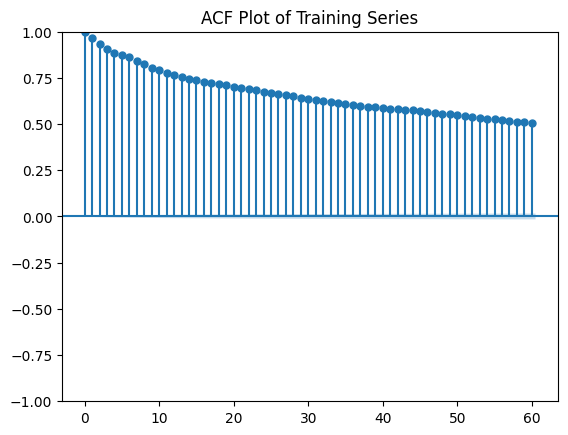

In [ ]:
plt.figure(figsize = (10,5))
plot_acf(ts_train, 
         lags = 60, 
         alpha=0.05  # 95% confidence interval
         )
plt.title("ACF Plot of Training Series")
plt.show()

The ACF has a smooth, monotonic decay and does not show a sharp cutoff at any specific lag. This pattern is characteristic of an AR‑type process rather than an MA‑type process. Because of this, the moving‑average component appears weak or possibly absent. Therefore, the MA order should be small — typically ``q = 0``, or at most ``q = 1``.

##### PACF (Partial Autocorrelation Function)

<Figure size 1000x500 with 0 Axes>

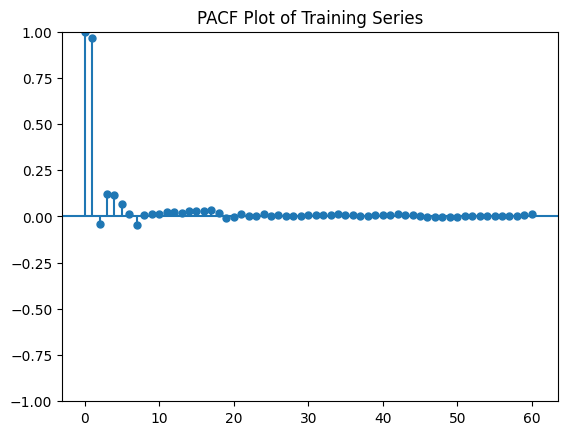

In [ ]:
plt.figure(figsize=(10,5))
plot_pacf(ts_train, 
          lags = 60, 
          method = "ywm", 
          alpha = 0.05   # 95% confidence interval
          )   
plt.title("PACF Plot of Training Series")
plt.show()

The PACF shows two very strong spikes at lags 1 and 2, after which the values drop quickly to near zero and stay close to zero for higher lags. This pattern indicates a clear cutoff after lag 2, which is characteristic of an autoregressive process of order 2. Therefore, the appropriate AR order suggested by the PACF is ``p = 1`` or ``p = 2``.

In [74]:
p = range(0, 2)   # p = 0,1,2,3   <-- this comment is wrong
d = [0]             # d = 0
q = range(0, 2)   # q = 0,1

pdq = list(itertools.product(p, d, q))
pdq

[(0, 0, 0), (0, 0, 1), (1, 0, 0), (1, 0, 1)]

In [ ]:
results = []
models = {}

start_time = time.time()   # Start timer

for order in pdq:
    try:
        model = ARIMA(ts_train, order=order)
        fitted = model.fit()
        models[order] = fitted
        results.append([order, fitted.aic])
    except:
        # Some combinations may fail to converge
        continue

# Calculate and print the elapsed time
end_time = time.time()
print(f"Elapsed time: {end_time - start_time:.2f} seconds")

aic_df = pd.DataFrame(results, 
                      columns = ["Order (p,d,q)", "AIC"]).sort_values("AIC")
print(aic_df)

best_order = aic_df.iloc[0]["Order (p,d,q)"]
print("\nBest model based on AIC:", best_order)

best_model = models[best_order]

Elapsed time: 133.99 seconds

Best model based on AIC: (1, 0, 1)


In [83]:
best_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                SARIMAX Results                                
===============================================================================
Dep. Variable:     global_active_power   No. Observations:               838860
Model:                  ARIMA(1, 0, 1)   Log Likelihood               21054.273
Date:                 Fri, 27 Mar 2026   AIC                         -42100.546
Time:                         22:42:26   BIC                         -42053.987
Sample:                     12-16-2006   HQIC                        -42087.642
                          - 07-21-2008                                         
Covariance Type:                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4783      0.012     40.617      0.000       0.455       0.501
ar.L1          0.9625      0.000   3739.315      0.000       0.962       0.963
ma.L1          0.0550      0.000    125.355      0.000       0.054       0.056
sigma2         0.0557   2.51e-05   2217.948      0.000       0.056       0.056
===================================================================================
Ljung-Box (L1) (Q):                  25.51   Jarque-Bera (JB):          31226164.78
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.71   Skew:                             0.94
Prob(H) (two-sided):                  0.00   Kurtosis:                        32.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [82]:
# Train predictions (in-sample)
y_train_pred = best_model.fittedvalues
y_train_pred = y_train_pred.reindex(ts_train.index)

# Validation predictions (out-of-sample)
n_val = len(ts_val)
y_val_pred = best_model.forecast(steps=n_val)

evaluate_model(
    model_name= f"ARIMA{best_order}",
    y_train=ts_train,
    y_train_pred=y_train_pred,
    y_val=ts_val,
    y_val_pred=y_val_pred
)

,Model,Train RMSE,Val RMSE,overfit_score,diagnosis
0,"ARIMA(1, 0, 1)",0.236,0.756,3.203,Overfitting


##### `auto_arima`

In [ ]:
from statsmodels.tsa.seasonal import STL

stl = STL(ts_train, period=1440).fit()
stl.plot()

In [ ]:
from pmdarima.utils import seasonal_period

m = seasonal_period(ts_train)
m

ImportError: cannot import name 'seasonal_period' from 'pmdarima.utils' (c:\Users\dersi\miniconda3\envs\py310\lib\site-packages\pmdarima\utils\__init__.py)

In [ ]:
from pmdarima import auto_arima

model = auto_arima(
    ts_train,
    seasonal= False,      # True if SARIMA
    trace= True,          # prints model search
    error_action= 'ignore',
    suppress_warnings= True,
    stepwise=True        # fast stepwise search
)

model.summary()

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

---

#### LSTM

In [ ]:
X_train_arr = train_df[features].values
X_test_arr = test_df[features].values
y_train_arr = train_df[target].values
y_test_arr = test_df[target].values

# Reshape to 3D for LSTM: (samples, timesteps, features)
X_train_lstm = X_train_arr.reshape((X_train_arr.shape[0], 
                                    1, 
                                    X_train_arr.shape[1]))
X_test_lstm = X_test_arr.reshape((X_test_arr.shape[0], 
                                  1, 
                                  X_test_arr.shape[1]))

In [ ]:
# Define model
model = Sequential()
model.add(LSTM(units= 50, 
               input_shape=(1, X_train_arr.shape[1])))
model.add(Dense(1))
model.compile(optimizer= Adam(learning_rate= 0.001), 
              loss= 'mse')

# Train
history = model.fit(X_train_lstm, 
                    y_train_arr,
                    epochs= 20,
                    batch_size= 64,
                    verbose= 1)

# Predict
y_test_pred = model.predict(X_test_lstm).flatten()

# Metrics
test_metrics = calculate_metrics(y_test_arr, 
                                 y_test_pred, 
                                 'LSTM (Test)')

# Combine results
error_df = pd.concat([error_df,
                      pd.DataFrame([test_metrics])], 
                      ignore_index= True)

# Show
error_df

##### Lagged LSTM

In [ ]:
# Define helper
def create_lagged_sequences(X, y, n_lags=10):
    Xs, ys = [], []
    for i in range(n_lags, len(X)):
        Xs.append(X[i-n_lags:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# Choose lag size
n_lags = 5

# Create sequences
X_train_seq, y_train_seq = create_lagged_sequences(X_train_arr, 
                                                   y_train_arr, 
                                                   n_lags)
X_test_seq, y_test_seq = create_lagged_sequences(X_test_arr, 
                                                 y_test_arr, 
                                                 n_lags)

# Define model
model = Sequential()
model.add(LSTM(units= 50, 
               input_shape= (n_lags, X_train_arr.shape[1])))
model.add(Dense(1))
model.compile(optimizer= Adam(learning_rate= 0.001), 
              loss= 'mse')

# Train
history = model.fit(X_train_seq, 
                    y_train_seq,
                    epochs= 20,
                    batch_size= 64,
                    verbose= 1)

# Predict
y_test_pred = model.predict(X_test_seq).flatten()

# Metrics
test_metrics = calculate_metrics(y_test_seq, 
                                 y_test_pred, 
                                 'Lagged LSTM (Test)')

# Update results
error_df = pd.concat([error_df,
                      pd.DataFrame([test_metrics])], 
                      ignore_index=True)

# Show results
error_df

### Train Models with Dummy Variable `weekday`

#### Linear Regression

In [ ]:
# Create dummy variables for weekday
df = pd.get_dummies(df,
                    columns= ['weekday'],
                    drop_first= True)

# Define features and target
features = ['sub_metering_1', 'sub_metering_2', 'sub_metering_3'] + \
           [col for col in df.columns if col.startswith('weekday_')]
target = 'global_active_power'

X = df[features]
y = df[target]

# Time-series split (e.g. 90% train, 10% test)
# Find the 90th percentile timestamp
split_point = df['date_time'].quantile(0.9)

# Train = all rows up to 90% quantile
X_dummy_train = X[df['date_time'] <= split_point]
y_dummy_train = y[df['date_time'] <= split_point]

# Test = all rows after 90% quantile
X_dummy_test = X[df['date_time'] > split_point]
y_dummy_test = y[df['date_time'] > split_point]

# Train linear regression model
lr = LinearRegression()
lr.fit(X_dummy_train, y_dummy_train)

# 6. Predict and evaluate
y_dummy_test_pred = lr.predict(X_dummy_test)

# 7. Collect results
test_metrics = calculate_metrics(y_dummy_test, 
                                 y_dummy_test_pred, 
                                 'Linear Regression + Weekday (Test)')


# Update results
error_df = pd.concat([error_df,
                      pd.DataFrame([test_metrics])], 
                      ignore_index= True)

# Show results
error_df

---

#### Gradient Boosting Regression

In [ ]:
# 1. Define and train the model
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_dummy_train, y_dummy_train)

# 2. Predict
y_dummy_test_pred = gbr.predict(X_dummy_test)

# 3. Collect metrics
test_metrics = calculate_metrics(y_dummy_test, 
                                 y_dummy_test_pred, 
                                 'Gradient Boosting + Weekday (Test)')

# 4. Add to error_df
error_df = pd.concat([error_df, 
                      pd.DataFrame([test_metrics])], 
                      ignore_index=True)

# 5. Show updated table
error_df

### The Final Test Table

In [ ]:
error_df.sort_values(by= 'RMSE', 
                     ascending= True)\
        .reset_index(drop= True)


### Hyperparameter Tuning

#### Random Forest

In [ ]:
# Define model
rf = RandomForestRegressor(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV
grid_search = GridSearchCV(estimator= rf,
                           param_grid= param_grid,
                           cv= 3,
                           scoring= 'neg_root_mean_squared_error',
                           verbose=1,
                           n_jobs=-1)

# Fit
grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_

# Predict and evaluate
y_test_pred = best_rf.predict(X_test)
test_metrics = calculate_metrics(y_test, 
                                 y_test_pred, 
                                 'Tuned Random Forest (Test)')

# Append to error_df
error_ht_df = pd.concat([pd.DataFrame([test_metrics])],
                      ignore_index=True)

error_ht_df

---

#### Gradient Boosting

In [ ]:
# Define model
gbr = GradientBoostingRegressor(random_state= 42)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.1, 0.05],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator= gbr,
    param_grid= param_grid,
    cv= 3,
    scoring= 'neg_root_mean_squared_error',
    n_jobs= -1,
    verbose= 1
)

# Fit to training data
grid_search.fit(X_train, y_train)

# Best estimator
best_gbr = grid_search.best_estimator_

# Predict on test data
y_test_pred = best_gbr.predict(X_test)

# Collect metrics
test_metrics = calculate_metrics(y_test, 
                                 y_test_pred, 
                                 'Tuned Gradient Boosting (Test)')

# Add to error_df
error_ht_df = pd.concat([error_ht_df,
                        pd.DataFrame([test_metrics])],
                        ignore_index= True)

# Show results
error_ht_df

## Evaluation

### Feature Importance

In [ ]:
# Mapping for readable names
name_map = {
    "sub_metering_1": "Kitchen",
    "sub_metering_2": "Laundry Room",
    "sub_metering_3": "Water Heater & AC"
}

# Get feature importances
importances = best_gbr.feature_importances_

# Create DataFrame and map readable names
feat_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})
feat_importance_df['Readable Name'] = feat_importance_df['Feature'].map(name_map)
feat_importance_df = feat_importance_df.sort_values(by= 'Importance', 
                                                    ascending= False)

In [ ]:
# Plot with seaborn
plt.figure(figsize= (8,5))

ax = sns.barplot(data= feat_importance_df,
                 x= "Importance",
                 y= "Readable Name",
                 color= "darkorange")

# Invert y-axis so the most important feature is at the top
# ax.invert_yaxis()

# Add value labels
for container in ax.containers:
    ax.bar_label(container, 
                 fmt= "%.3f",
                 # Place labels at the top edge
                 label_type= "edge", 
                 fontsize= 10,
                 fontweight= "bold", 
                 # Push the label into the bar
                 padding= -40,
                 color= 'white')
    

# Add title and labels
plt.title("Feature Importance (Tuned Gradient Boosting)", fontsize=14)
plt.xlabel("Importance", fontsize= 12)
plt.tight_layout()
# plt.savefig(f"{att}.png", dpi=600)
plt.show()

---

### Visualisation of Predictions

In [ ]:
test_df = test_df.set_index('date_time')
# Suppose y_test and y_test_pred are numpy arrays, convert them to DataFrames with the same index as your test set
test_pred_df = pd.DataFrame(y_test_pred, 
                            index= test_df.index, 
                            columns= ['Prediction'])
test_true_df = test_df[[target]]  # target = 'global_active_power'

# Merge predictions into the original test DataFrame (or into the original df if you want full data)
df_merged = test_true_df.merge(test_pred_df, 
                               left_index= True, 
                               right_index= True, 
                               how= 'left')

# Plot
ax = df_merged[[target]].plot(figsize=(15, 5))
df_merged['Prediction'].plot(ax=ax, style='--')
plt.legend(['Original Data', 'Predictions'])
ax.set_title('Original and Predicted Global Active Power (Test Set)')
plt.show()

### Resampling

Resampling options:
- `'H'` for hourly frequency
- `'D'` for daily frequency
- `'B'` for business day frequency
- `'W'` for weekly frequency
- `'M'` for month end frequency
- `'Q'` for quarter end frequency
- `'A'` for year end frequency

In [ ]:
# Resample numeric columns of df_merged
numeric_cols = df_merged\
               .select_dtypes(include= 'number')\
               .columns

df_hour = df_merged[numeric_cols].resample('H').mean()
df_daily = df_merged[numeric_cols].resample('D').mean()

dfs = [(df_hour, 'Hourly'), (df_daily, 'Daily')]

for df_resampled, title in dfs:
    ax = df_resampled[['global_active_power']].plot(figsize= (15, 5))
    if 'Prediction' in df_resampled.columns:
        df_resampled['Prediction'].plot(ax= ax, style='--')
    plt.legend(['Original Data', 'Predictions'])
    ax.set_title(f'Power Consumption Prediction by {title}')
    plt.show()


---

# PDF and environment.yml

In [89]:
!conda env export -n py310 > environment.yml

In [ ]:
!jupyter nbconvert --to webpdf NB.ipynb